MODELO DE DISPATCHING. 

PARTE I: ESTRUCTURA INICIAL.

Librerías

In [536]:
import pypsa #PyPSA: Python for Power System Analysis
import pandas as pd #Pandas: Biblioteca para manipulación y análisis de datos
import numpy as np #Numpy: Biblioteca para cálculos numéricos
import matplotlib.pyplot as plt #Matplotlib: Biblioteca para creación de gráficos
import matplotlib.dates as mdates #Matplotlib.dates: Módulo para manejar fechas en gráficos

pypsa.options.api.new_components_api = True # Activar la nueva API de componentes de PyPSA

Creación de Snapshot

In [537]:
# (1) Definir el periodo. 
hours=pd.date_range("2025-01-01", periods=24*7, freq="h")

# (2) Crear la red vacía con esos snapshots
network=pypsa.Network()
network.set_snapshots(hours)

# (3) Calcular el peso de cada hora para extrapolar a un año completo
hours_per_year=365*24
snapshot_weight=len(hours)
single_weight=hours_per_year/snapshot_weight

#(4) Asignar el peso a cada snapshot
network.snapshot_weightings = pd.DataFrame(
    index=network.snapshots,
    data={
        "objective": single_weight,
        "generators": single_weight,
        "stores": 1.0,
    }
)

In [538]:
data = pd.read_excel(
    "modelo_dispatching_españa_portugal_unido.xlsx",
    sheet_name=None,
    engine="openpyxl"
)

Lectura de Hojas de Datos (excel integrado)

In [539]:
# Verificación de correcta lectura de datos
print(data.keys())  # Muestra las hojas disponibles en el archivo Excel

dict_keys(['Guide Sheet', 'carriers', 'buses', 'generators', 'loads', 'links', 'storage_units', 'store', 'demands', 'run_of_river_inflow', 'profiles', 'Hoja1'])


In [540]:

file = "modelo_dispatching_españa_portugal_unido.xlsx"
hours_week = 168 # flexible para definir semanas
hours_year = 8760 # flexible para definir años
#---------------------------------------------------------------------------------------------------------
# Perfiles de generación renovable
df_profiles = pd.read_excel(file, sheet_name="profiles") # Leer la hoja 'profiles' del archivo Excel
df_profiles["date"] = pd.to_datetime(df_profiles["date"]) # Asegurar que la columna de fecha es datetime
    # ESPAÑA
ES_solar_profile     = df_profiles["ES_solar_profile"].iloc[:hours_week].reset_index(drop=True) 
ES_wind_profile      = df_profiles["ES_wind_profile"].iloc[:hours_week].reset_index(drop=True) 
ES_SRES_wind_profile      = df_profiles["ES_wind_profile"].iloc[:hours_week].reset_index(drop=True)
ES_SRES_solar_profile      = df_profiles["ES_solar_profile"].iloc[:hours_week].reset_index(drop=True)
    # PORTUGAL
PT_solar_profile     = df_profiles["PT_solar_profile"].iloc[:hours_week].reset_index(drop=True) 
PT_wind_profile     = df_profiles["PT_wind_profile"].iloc[:hours_week].reset_index(drop=True) 
PT_SRES_wind_profile      = df_profiles["PT_wind_profile"].iloc[:hours_week].reset_index(drop=True)
PT_SRES_solar_profile      = df_profiles["PT_solar_profile"].iloc[:hours_week].reset_index(drop=True)
#---------------------------------------------------------------------------------------------------------
# Run of river inflow
df_run_of_river_inflow = pd.read_excel(file, sheet_name="run_of_river_inflow") # Leer la hoja 'profiles' del archivo Excel
df_run_of_river_inflow["date"] = pd.to_datetime(df_run_of_river_inflow["date"]) # Asegurar que la columna de fecha es datetime
    # ESPAÑA
ES_hydraulic_profile = df_run_of_river_inflow["ES_hydraulic_profile"].iloc[:hours_week].reset_index(drop=True) 
    # PORTUGAL
PT_hydraulic_profile = df_run_of_river_inflow["PT_hydraulic_profile"].iloc[:hours_week].reset_index(drop=True)
#---------------------------------------------------------------------------------------------------------
# Demandas
df_demand2040 = pd.read_excel(file, sheet_name="demands") 
df_profiles["date"] = pd.to_datetime(df_profiles["date"]) 
    # ESPAÑA
ES_demand_2040 = df_demand2040["ES_demand_2040"].iloc[:hours_week].reset_index(drop=True)
ES_hydrogen_demand = df_demand2040["ES_hydrogen_demand"].iloc[:hours_week].reset_index(drop=True)
    # PORTUGAL
PT_demand_2040 = df_demand2040["PT_demand_2040"].iloc[:hours_week].reset_index(drop=True)
PT_hydrogen_demand = df_demand2040["PT_hydrogen_demand"].iloc[:hours_week].reset_index(drop=True)


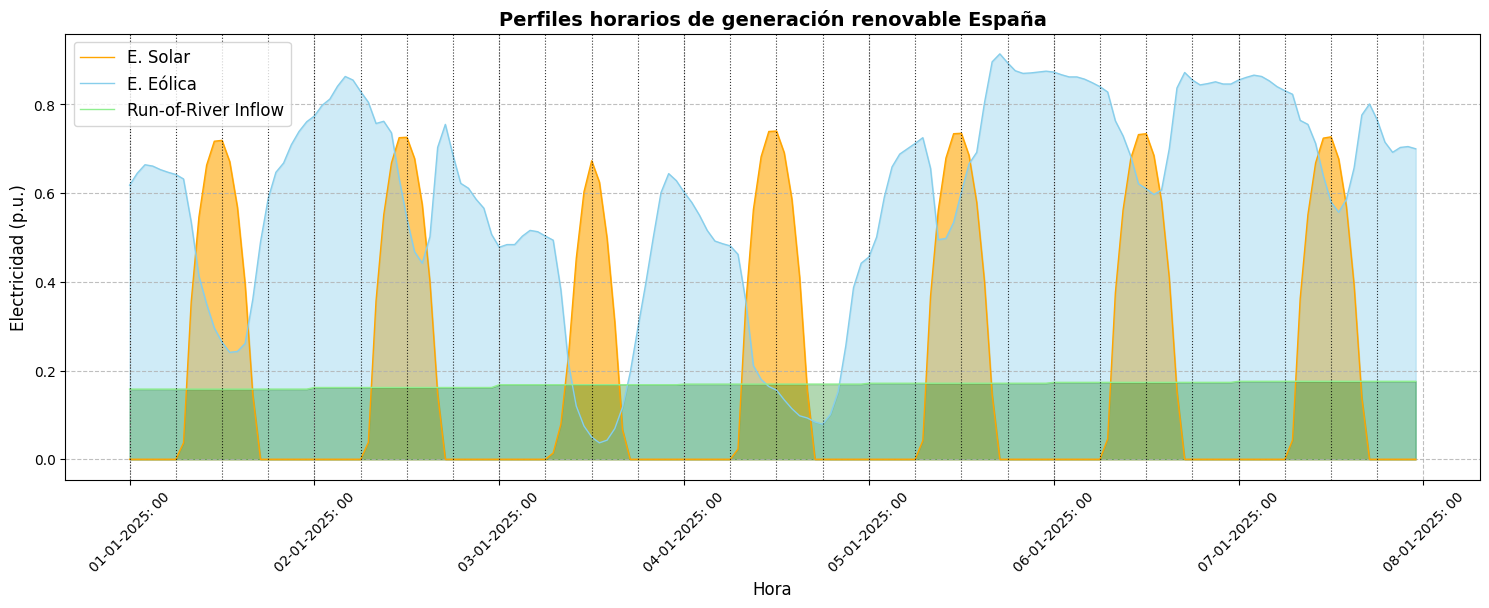

In [541]:
# GRAFICAR

# Gráfica de Perfiles Horarios de Generación Renovable.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") # para que grafique una semana completa (tengo datos para 1 año)
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, ES_solar_profile, label="E. Solar", color="orange", linewidth=1, linestyle="-")
plt.plot(hours, ES_wind_profile, label="E. Eólica", color="skyblue", linewidth=1, linestyle="-")
plt.plot(hours, ES_hydraulic_profile, label="Run-of-River Inflow", color="lightgreen", linewidth=1, linestyle="-")
plt.title("Perfiles horarios de generación renovable España", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Electricidad (p.u.)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.fill_between(hours, ES_solar_profile, color="orange", alpha=0.6)
plt.fill_between(hours, ES_wind_profile, color="skyblue", alpha=0.4)
plt.fill_between(hours, ES_hydraulic_profile, color="green", alpha=0.3)

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.8, alpha=0.8)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()



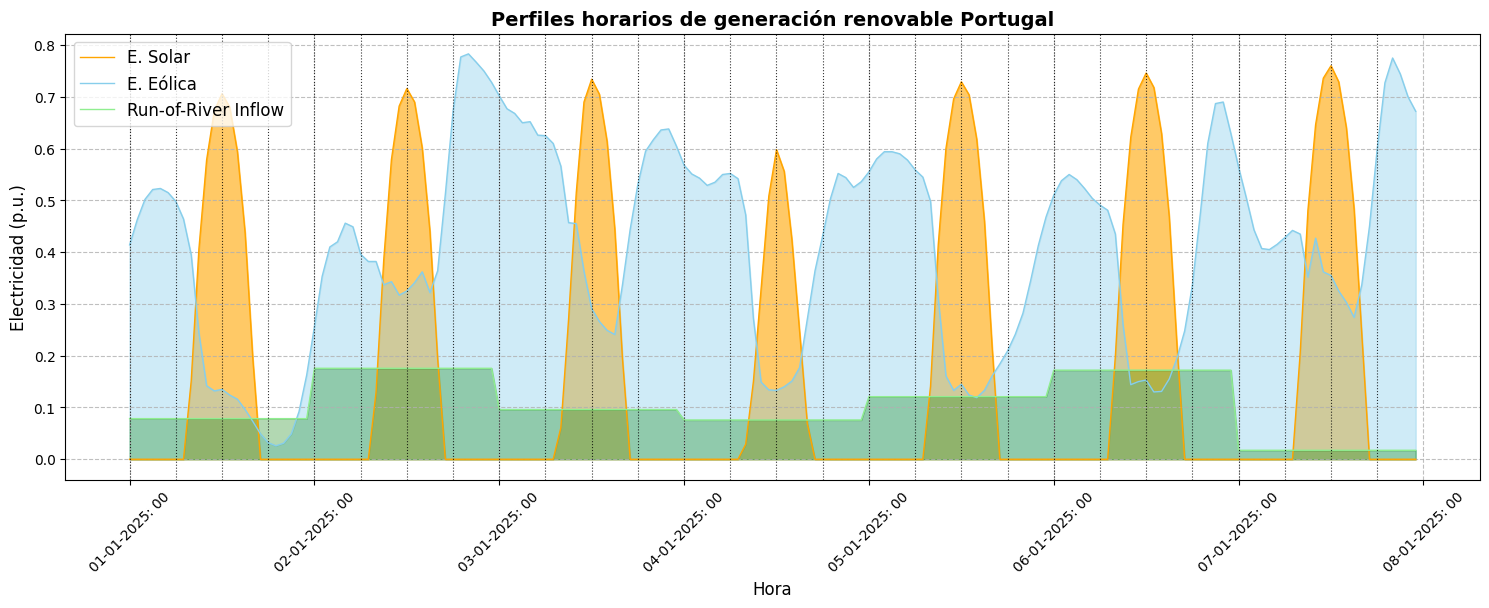

In [542]:
# GRAFICAR

# Gráfica de Perfiles Horarios de Generación Renovable.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") # para que grafique una semana completa (tengo datos para 1 año)
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, PT_solar_profile, label="E. Solar", color="orange", linewidth=1, linestyle="-")
plt.plot(hours, PT_wind_profile, label="E. Eólica", color="skyblue", linewidth=1, linestyle="-")
plt.plot(hours, PT_hydraulic_profile, label="Run-of-River Inflow", color="lightgreen", linewidth=1, linestyle="-")
plt.title("Perfiles horarios de generación renovable Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Electricidad (p.u.)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.fill_between(hours, PT_solar_profile, color="orange", alpha=0.6)
plt.fill_between(hours, PT_wind_profile, color="skyblue", alpha=0.4)
plt.fill_between(hours, PT_hydraulic_profile, color="green", alpha=0.3)
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.8, alpha=0.8)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\2008595108.py:2: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



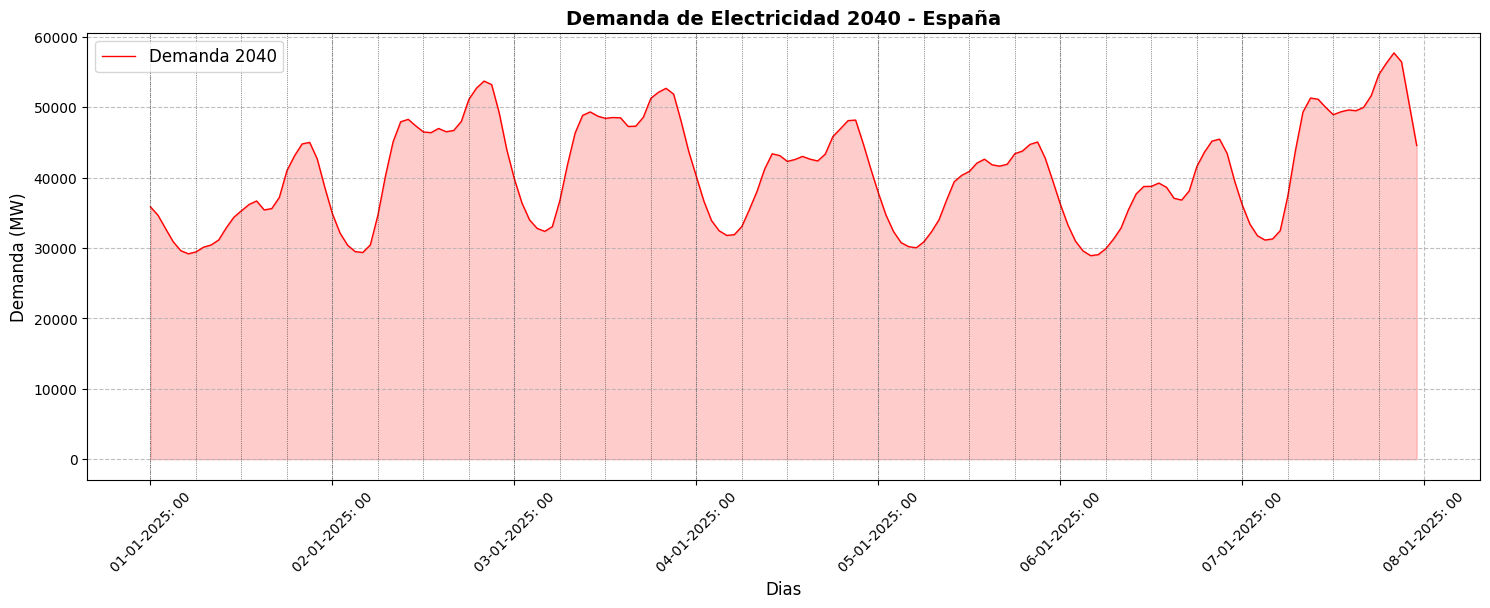

In [543]:
# Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="H") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, ES_demand_2040, label="Demanda 2040", color="red", linewidth=1, linestyle="-")
plt.fill_between(hours, ES_demand_2040, color="red", alpha=0.2)
plt.title("Demanda de Electricidad 2040 - España",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.8)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

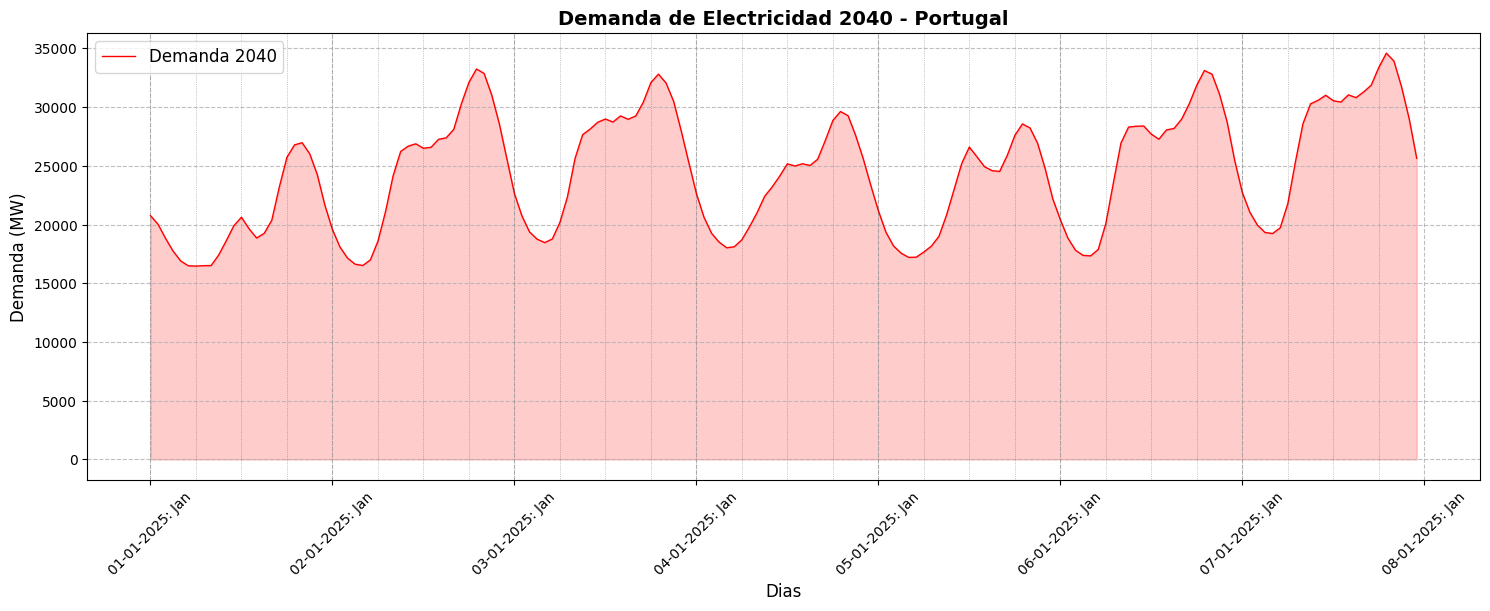

In [544]:
# Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, PT_demand_2040, label="Demanda 2040", color="red", linewidth=1, linestyle="-")
plt.fill_between(hours, PT_demand_2040, color="red", alpha=0.2)
plt.title("Demanda de Electricidad 2040 - Portugal",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %h'))
plt.xticks(rotation=45)
plt.show()

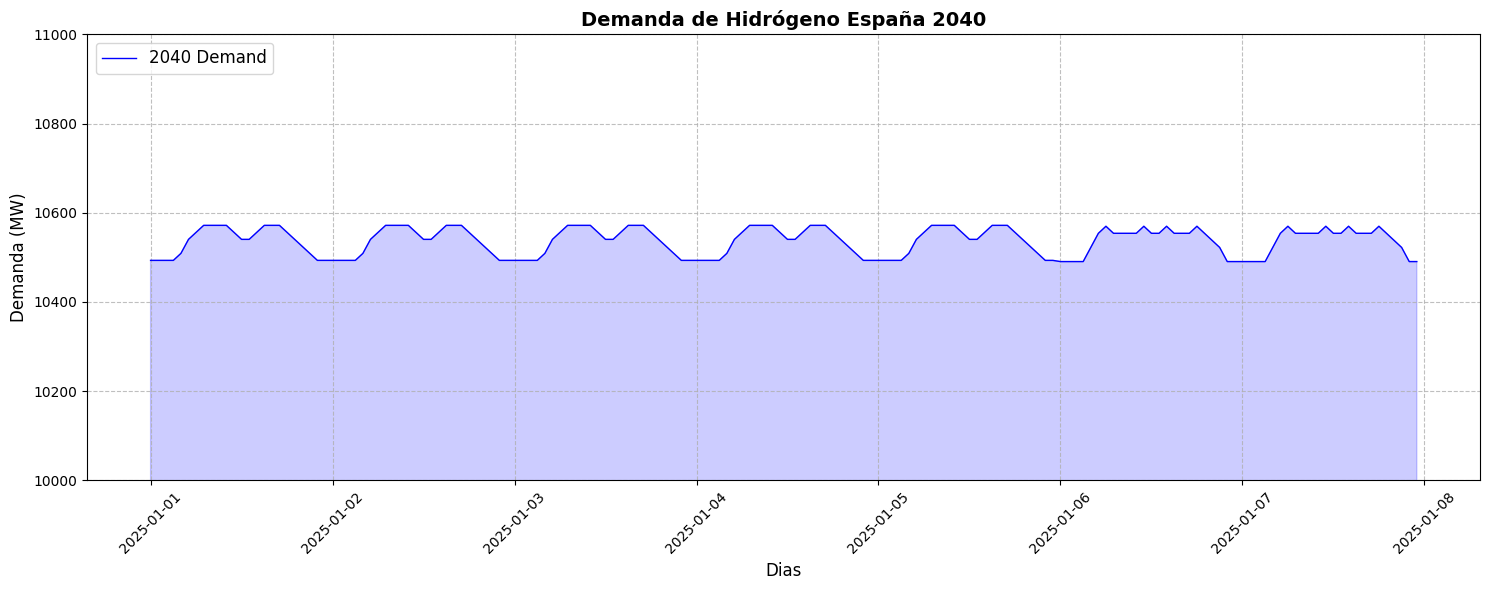

In [545]:
 # Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, ES_hydrogen_demand, label="2040 Demand", color="blue", linewidth=1, linestyle="-")
plt.fill_between(hours, ES_hydrogen_demand, color="blue", alpha=0.2)
plt.title("Demanda de Hidrógeno España 2040",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.ylim(10000, 11000)

plt.xticks(rotation=45)
plt.show()

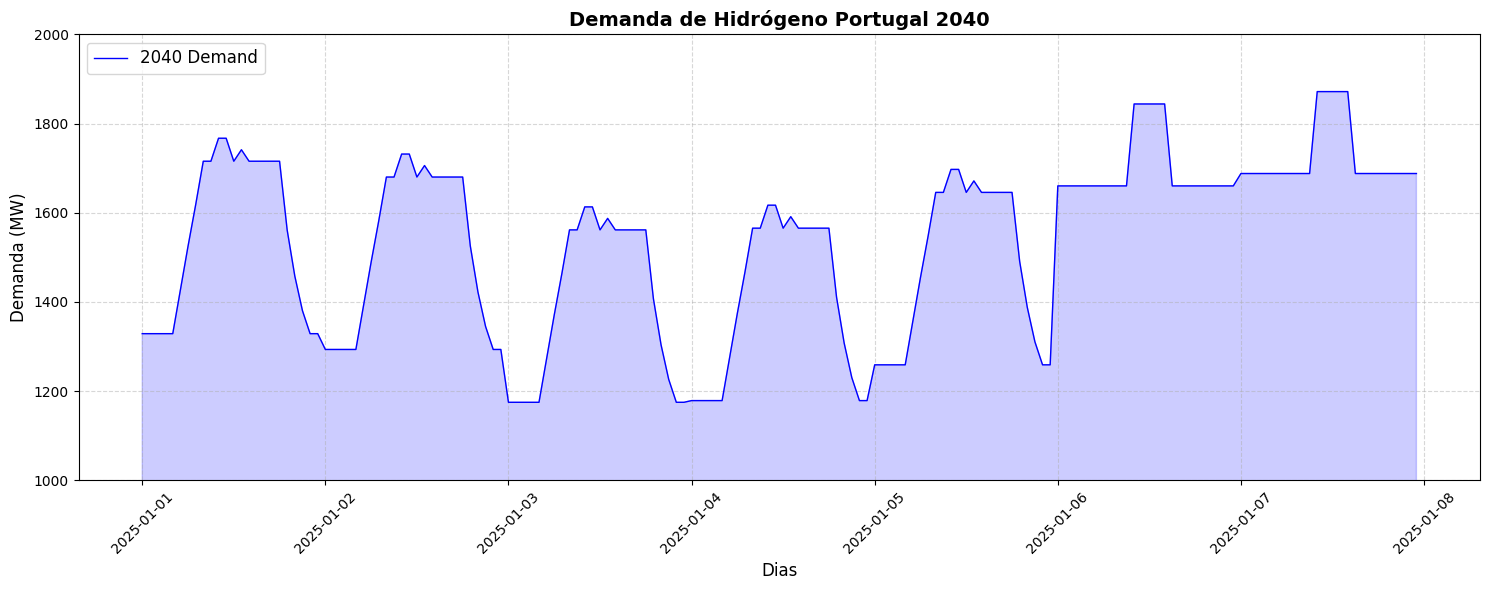

In [546]:
 # Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, PT_hydrogen_demand, label="2040 Demand", color="blue", linewidth=1, linestyle="-")
plt.fill_between(hours, PT_hydrogen_demand, color="blue", alpha=0.2)
plt.title("Demanda de Hidrógeno Portugal 2040",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.ylim(1000,2000)

plt.xticks(rotation=45)
plt.show()

PARTE II: CREACIÓN DEL ENTORNO: Llamada a Componentes

In [547]:
# CARRIERS
df_carriers = data["carriers"]

for _, carrier in df_carriers.iterrows():
    network.add(
        "Carrier",
        carrier["name"].strip(),
        overwrite=carrier["overwrite"]
    )

# Verificación con API moderna
print("\n=== Carriers añadidos ===")
print(network.carriers.static)


=== Carriers añadidos ===
               co2_emissions color nice_name  max_growth  max_relative_growth
name                                                                         
AC                       0.0                         inf                  0.0
water                    0.0                         inf                  0.0
wind                     0.0                         inf                  0.0
gas                      0.0                         inf                  0.0
solar                    0.0                         inf                  0.0
grid_import              0.0                         inf                  0.0
biomass                  0.0                         inf                  0.0
hydrogen                 0.0                         inf                  0.0
load_shedding            0.0                         inf                  0.0


In [548]:
# BUSES
df_buses = data["buses"]

for _, bus in df_buses.iterrows():
    network.add(
        "Bus",
        bus["name"].strip(),
        carrier=bus["carrier"].strip(),
        overwrite=bus["overwrite"]
    )

# Verificación con API moderna
print("\n=== Buses añadidos ===")
print(network.buses.static)  



=== Buses añadidos ===
                           v_nom type    x    y   carrier unit location  \
name                                                                      
ES_electricity_market_bus    1.0       0.0  0.0        AC                 
ES_water_bus                 1.0       0.0  0.0     water                 
ES_gas_bus                   1.0       0.0  0.0       gas                 
ES_hydrogen_bus              1.0       0.0  0.0  hydrogen                 
ES_SRES_bus                  1.0       0.0  0.0        AC                 
PT_electricity_market_bus    1.0       0.0  0.0        AC                 
PT_water_bus                 1.0       0.0  0.0     water                 
PT_gas_bus                   1.0       0.0  0.0       gas                 
PT_hydrogen_bus              1.0       0.0  0.0  hydrogen                 
PT_SRES_bus                  1.0       0.0  0.0        AC                 

                           v_mag_pu_set  v_mag_pu_min  v_mag_pu_max control

In [549]:
# GENERADORES

df_generators = data["generators"]

for _, gen in df_generators.iterrows(): 
    gen_name = gen["name"].strip() 
    carrier_key = gen["carrier"].strip().lower() 
    
    # Detectar si es ES o PT según el bus
    country = gen["bus"][:2]   # ES / PT

    # Crear el generador estático
    network.add( 
        "Generator",
        gen_name,
        bus=gen["bus"],
        p_nom=gen["p_nom"],
        # p_nom_extendable=gen["p_nom_extendable"],
        # p_nom_max=gen["p_nom_max"],
        marginal_cost=gen["marginal_cost"],
        carrier=gen["carrier"],
        overwrite=gen["overwrite"]
    )

    # Seleccionar perfil correcto según país + carrier
    if carrier_key == "solar":
        profile = ES_solar_profile if country == "ES" else PT_solar_profile
        network.generators.dynamic["p_max_pu"][gen_name] = profile.values
    elif carrier_key == "wind":
        profile = ES_wind_profile if country == "ES" else PT_wind_profile
        network.generators.dynamic["p_max_pu"][gen_name] = profile.values
    elif carrier_key == "water":
        profile = ES_hydraulic_profile if country == "ES" else PT_hydraulic_profile
        network.generators.dynamic["p_max_pu"][gen_name] = profile.values
    else:
        continue  # carrier no renovable → no tiene perfil dinámico



In [550]:
print(network.generators)
print(network.generators.dynamic["p_max_pu"].columns)

'Generator' Components
Index(['ES_solar', 'ES_wind', 'ES_water', 'ES_SRES_solar', 'ES_SRES_wind',
       'PT_solar', 'PT_wind', 'PT_water', 'PT_SRES_solar', 'PT_SRES_wind'],
      dtype='object', name='name')


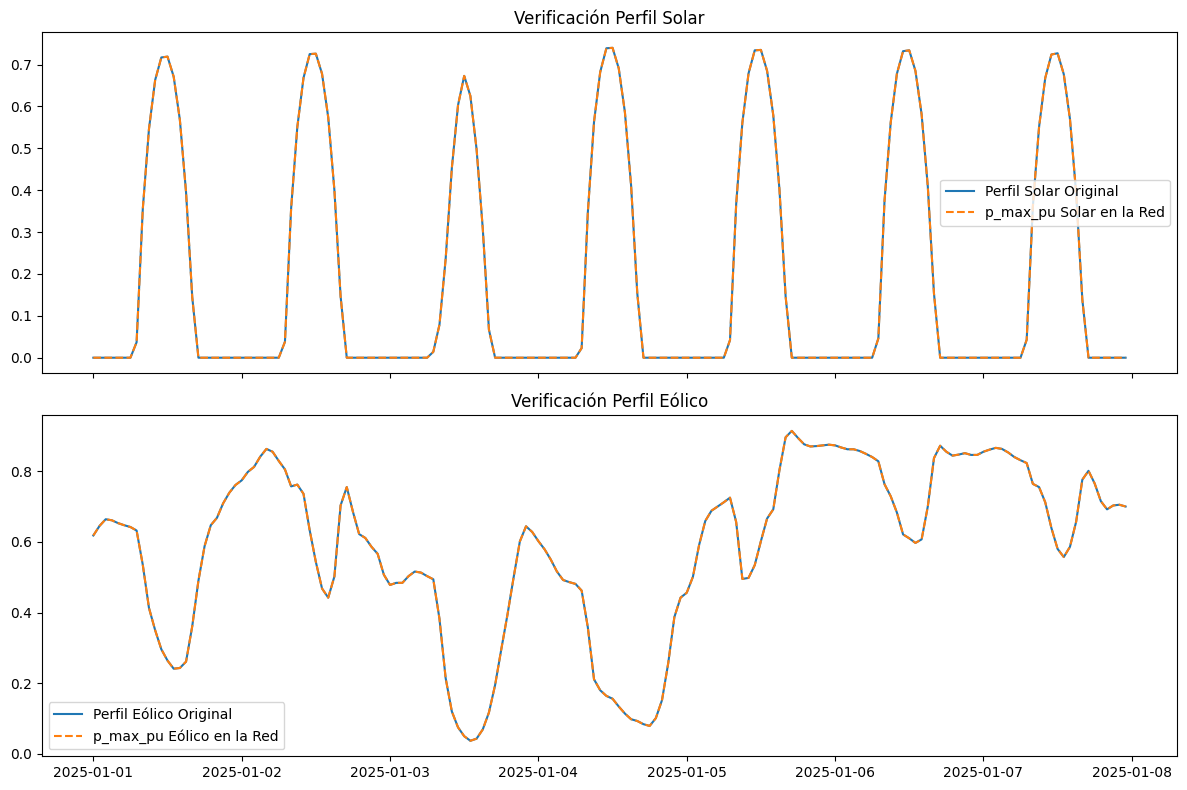

In [551]:
# Verificación de perfiles asignados correctamente: ES
ES_solar_profile.index = network.snapshots[:len(ES_solar_profile)]
ES_wind_profile.index = network.snapshots[:len(ES_wind_profile)]

# Extraer perfiles desde la red
solar_pm = network.generators.dynamic["p_max_pu"]["ES_solar"]
wind_pm  = network.generators.dynamic["p_max_pu"]["ES_wind"]

# Gráfico
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(network.snapshots[:len(solar_pm)], ES_solar_profile, label="Perfil Solar Original")
axes[0].plot(network.snapshots[:len(solar_pm)], solar_pm, linestyle="--", label="p_max_pu Solar en la Red")
axes[0].set_title("Verificación Perfil Solar")
axes[0].legend()

axes[1].plot(network.snapshots[:len(wind_pm)], ES_wind_profile, label="Perfil Eólico Original")
axes[1].plot(network.snapshots[:len(wind_pm)], wind_pm, linestyle="--", label="p_max_pu Eólico en la Red")
axes[1].set_title("Verificación Perfil Eólico")
axes[1].legend()

plt.tight_layout()
plt.show()



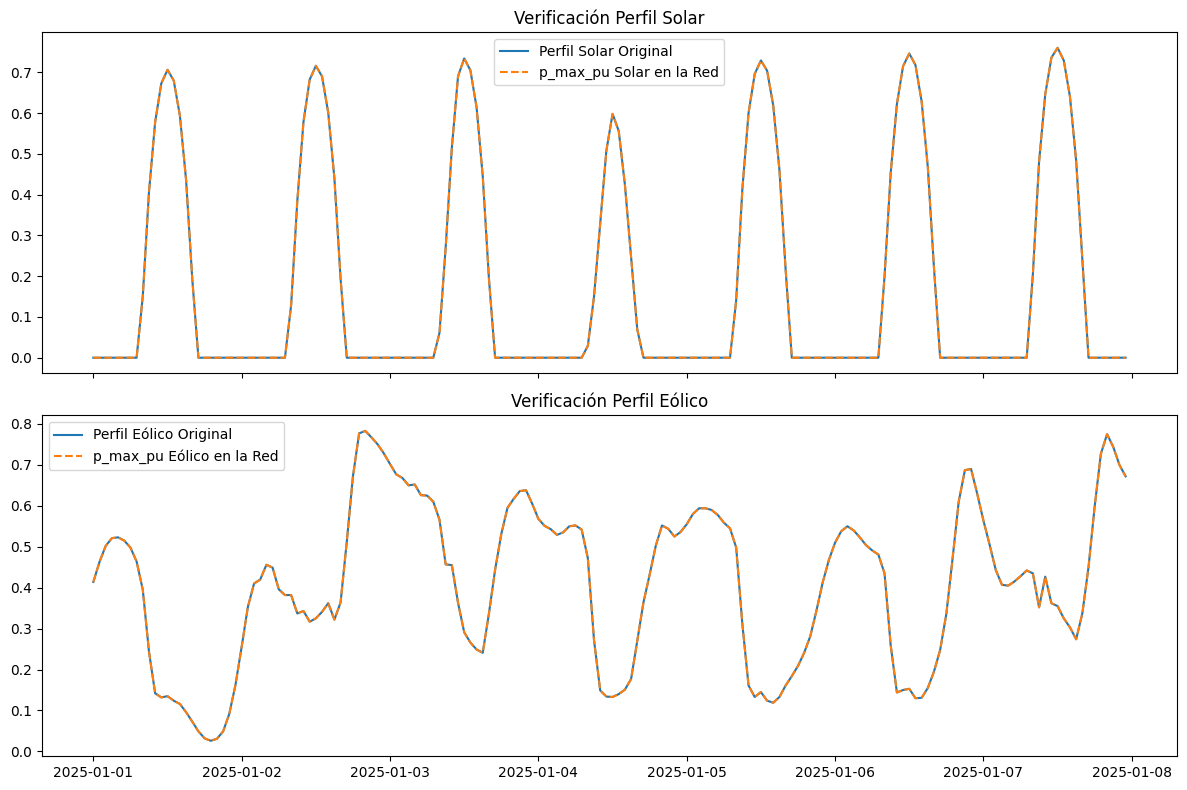

In [552]:
# Verificación de perfiles asignados correctamente: PT
PT_solar_profile.index = network.snapshots[:len(PT_solar_profile)]
PT_wind_profile.index = network.snapshots[:len(PT_wind_profile)]

# Extraer perfiles desde la red
solar_pm = network.generators.dynamic["p_max_pu"]["PT_solar"]
wind_pm  = network.generators.dynamic["p_max_pu"]["PT_wind"]

# Gráfico
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(network.snapshots[:len(solar_pm)], PT_solar_profile, label="Perfil Solar Original")
axes[0].plot(network.snapshots[:len(solar_pm)], solar_pm, linestyle="--", label="p_max_pu Solar en la Red")
axes[0].set_title("Verificación Perfil Solar")
axes[0].legend()

axes[1].plot(network.snapshots[:len(wind_pm)], PT_wind_profile, label="Perfil Eólico Original")
axes[1].plot(network.snapshots[:len(wind_pm)], wind_pm, linestyle="--", label="p_max_pu Eólico en la Red")
axes[1].set_title("Verificación Perfil Eólico")
axes[1].legend()

plt.tight_layout()
plt.show()


In [553]:
# LOADS

# CREAR SERIES DE DEMANDA
    #ESPAÑA
ES_demand_hydrogen_series = pd.Series(df_demand2040['ES_hydrogen_demand'].iloc[:len(network.snapshots)].values, index=network.snapshots)
ES_demand_series = pd.Series(df_demand2040['ES_demand_2040'].iloc[:len(network.snapshots)].values, index=network.snapshots)
    #PORTUGAL
PT_demand_hydrogen_series = pd.Series(df_demand2040['PT_hydrogen_demand'].iloc[:len(network.snapshots)].values, index=network.snapshots)
PT_demand_series = pd.Series(df_demand2040['PT_demand_2040'].iloc[:len(network.snapshots)].values, index=network.snapshots)

# Añadir variables estáticas
df_loads = data["loads"]
for _, load in df_loads.iterrows():
    network.add(
        "Load",
        load["name"].strip(),
        bus=load["bus"].strip(),
        carrier=load["carrier"].strip(),
        overwrite=load["overwrite"]
    )

# Asignar variables dinámicas
    #ESPAÑA
network.loads.dynamic["p_set"]["ES_hydrogen_demand"] = ES_demand_hydrogen_series.values
network.loads.dynamic["p_set"]["ES_demand_2040"] = ES_demand_series.values
    #PORTUGAL
network.loads.dynamic["p_set"]["PT_hydrogen_demand"] = PT_demand_hydrogen_series.values
network.loads.dynamic["p_set"]["PT_demand_2040"] = PT_demand_series.values

# Verificación con API moderna
print("\n=== Loads estáticos ===")
print(network.loads.static)

print("\n=== Primeras filas de p_set dinámico ===")
print(network.loads.dynamic["p_set"].head())



=== Loads estáticos ===
                                          bus   carrier type  p_set  q_set  \
name                                                                         
ES_demand_2040      ES_electricity_market_bus        AC         0.0    0.0   
ES_hydrogen_demand            ES_hydrogen_bus  hydrogen         0.0    0.0   
PT_demand_2040      PT_electricity_market_bus        AC         0.0    0.0   
PT_hydrogen_demand            PT_hydrogen_bus  hydrogen         0.0    0.0   

                    sign  active  
name                              
ES_demand_2040      -1.0    True  
ES_hydrogen_demand  -1.0    True  
PT_demand_2040      -1.0    True  
PT_hydrogen_demand  -1.0    True  

=== Primeras filas de p_set dinámico ===
name                 ES_hydrogen_demand  ES_demand_2040  PT_hydrogen_demand  \
snapshot                                                                      
2025-01-01 00:00:00         10493.06584    35845.954713         1328.747032   
2025-01-01 01:00:

In [554]:
df_links = data["links"]

for _, lk in df_links.iterrows():

    name = lk["name"].strip().lower()
    link_name = lk["name"].strip()

    # Detectar país desde bus0
    country = lk["bus0"][:2]   # ES / PT

    # Añadir link estático
    network.add(
        "Link",
        link_name,
        bus0=lk["bus0"].strip(),
        bus1=lk["bus1"].strip(),
        p_nom=lk["p_nom"],
        #p_max_pu=lk["p_max_pu"],
        #p_min_pu=lk["p_min_pu"],
        efficiency=lk["efficiency"],
        marginal_cost=lk["marginal_cost"],
        carrier=lk["carrier"],
        capital_cost=lk["capital_cost"],
        overwrite=lk["overwrite"]
    )



In [555]:
# Verificación
     
print("\n=== Resumen de todos los Links en la red ===")
print(network.links.static[['bus0','bus1','p_nom','efficiency','marginal_cost','carrier']])
for link_name in ["CCGT", "turbina", "pump", "electrolyzer"]:
        if link_name in network.links.static.index:
            row = network.links.static.loc[link_name]
            print(f"\n--- Detalle de {link_name} ---")
            print(f"Origen (bus0):        {row['bus0']}")
            print(f"Destino (bus1):       {row['bus1']}")
            print(f"Capacidad (p_nom):    {row['p_nom']} MW")
            print(f"Eficiencia:           {row['efficiency']*100:.1f}%")
            print(f"Coste marginal:       {row['marginal_cost']} €/MWh")
            print(f"Carrier:              {row['carrier']}")
            # Ramp limits solo para CCGT
            #if link_name == "CCGT":
            #    print(f"Ramp up limit:        {row['ramp_limit_up']} MW/h")
            #    print(f"Ramp down limit:      {row['ramp_limit_down']} MW/h")
        else:
            print(f"\n⚠️ El link '{link_name}' no se encontró en la red.")


=== Resumen de todos los Links en la red ===
                                                       bus0  \
name                                                          
ES_CCGT                                          ES_gas_bus   
ES_turbina                                     ES_water_bus   
ES_pump                           ES_electricity_market_bus   
ES_electrolyzer                   ES_electricity_market_bus   
ES_SRES_electrolyzer                            ES_SRES_bus   
ES_SRES_excedentes                              ES_SRES_bus   
PT_CCGT                                          PT_gas_bus   
PT_turbina                                     PT_water_bus   
PT_pump                           PT_electricity_market_bus   
PT_electrolyzer                   PT_electricity_market_bus   
PT_SRES_electrolyzer                            PT_SRES_bus   
PT_SRES_excedentes                              PT_SRES_bus   
ES_PT_interconexion_electricidad  ES_electricity_market_bus   
ES_PT_int

In [556]:
print("\nLINKS ESTÁTICOS:")
print(network.links.static.index)

print("\nCOLUMNAS EN p_max_pu:")
print(network.links.dynamic["p_max_pu"].columns)

print("\nCOLUMNAS EN p0:")
print(network.links_t.p0.columns)


LINKS ESTÁTICOS:
Index(['ES_CCGT', 'ES_turbina', 'ES_pump', 'ES_electrolyzer',
       'ES_SRES_electrolyzer', 'ES_SRES_excedentes', 'PT_CCGT', 'PT_turbina',
       'PT_pump', 'PT_electrolyzer', 'PT_SRES_electrolyzer',
       'PT_SRES_excedentes', 'ES_PT_interconexion_electricidad',
       'ES_PT_interconexion_hidrogeno', 'PT_ES_interconexion_electricidad',
       'PT_ES_interconexion_hidrogeno'],
      dtype='object', name='name')

COLUMNAS EN p_max_pu:
Index([], dtype='object', name='name')

COLUMNAS EN p0:
Index([], dtype='object', name='name')


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\4154381567.py:8: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



In [557]:

df_storage = data["storage_units"]

for _, st in df_storage.iterrows():
    name = st["name"].strip()

    soc0=0.5*st["p_nom"]*st["max_hours"]  # Estado de carga inicial al 50%

    # Añadir atributos estáticos
    network.add(
        "StorageUnit",
        name,
        bus=st["bus"].strip(),
        p_nom=st["p_nom"],
        max_hours=st["max_hours"],
        efficiency_store=st["efficiency_store"],
        efficiency_dispatch=st["efficiency_dispatch"],
        marginal_cost=st["marginal_cost"],
        carrier=st["carrier"],
        overwrite=st["overwrite"],
        #capital_cost=st("capital_cost"),  
        state_of_charge_initial= soc0, 
        cyclic_state_of_charge=False
    )

    print(f"✅ StorageUnit '{name}' añadida en bus {st['bus']}: {st['p_nom']} MW · {st['max_hours']} h")

# Verificación
print("\n=== Storage Units estáticos ===")
print(network.storage_units.static.head())

print("\n=== Storage Units dinámicos ===")
print(network.storage_units.dynamic.keys())


✅ StorageUnit 'ES_electricity_market_battery' añadida en bus ES_electricity_market_bus: 26698.52 MW · 4 h
✅ StorageUnit 'ES_hydrogen_storage' añadida en bus ES_hydrogen_bus: 10000.0 MW · 1000 h
✅ StorageUnit 'PT_electricity_market_battery' añadida en bus PT_electricity_market_bus: 3000.0 MW · 4 h

=== Storage Units estáticos ===
                                                     bus control type  \
name                                                                    
ES_electricity_market_battery  ES_electricity_market_bus      PQ        
ES_hydrogen_storage                      ES_hydrogen_bus      PQ        
PT_electricity_market_battery  PT_electricity_market_bus      PQ        

                                  p_nom  p_nom_mod  p_nom_extendable  \
name                                                                   
ES_electricity_market_battery  26698.52        0.0             False   
ES_hydrogen_storage            10000.00        0.0             False   
PT_electricity_

In [558]:
df_store = data["store"].copy()
 
# normaliza la columna a boolean REAL
df_store["cyclic_state_of_charge"] = (
    df_store["cyclic_state_of_charge"]
    .astype(str).str.strip().str.lower()
    .map({"true": True, "false": False, "1": True, "0": False, "nan": False})
)
 
# si algo no mapea, lo dejamos en False (o lanza error si prefieres)
df_store["cyclic_state_of_charge"] = df_store["cyclic_state_of_charge"].fillna(False)

In [559]:


for _, store in df_store.iterrows():
    network.add(
        "Store",
        store["name"].strip(),
        bus=store["bus"].strip(),
        e_nom=store["e_nom"],
        e_initial=store["e_initial"], 
        e_min_pu=store["e_min_pu"],
        e_max_pu=store["e_max_pu"],
        e_cyclic=store["cyclic_state_of_charge"],
        #capital_cost=store["capital_cost"],
        marginal_cost=store["marginal_cost"],
        carrier=store["carrier"],
        overwrite=store["overwrite"]
    )

    print(f"✅ Store '{store['name']}' añadida en bus {store['bus']}: "
          f"{store['e_nom']} MWh · inicial {store['e_initial']} MWh · "
          f"min {store['e_min_pu']} pu · max {store['e_max_pu']} pu · "
          f"coste marginal {store['marginal_cost']}")

# Verificación con API moderna
print("\n=== Stores estáticos ===")
print(network.stores.static.head())


✅ Store 'ES_embalse' añadida en bus ES_water_bus: 1387684000 MWh · inicial 1248915600 MWh · min 0.2 pu · max 0.9 pu · coste marginal 1
✅ Store 'PT_embalse' añadida en bus PT_water_bus: 3307600 MWh · inicial 2976840 MWh · min 0.2 pu · max 0.9 pu · coste marginal 1

=== Stores estáticos ===
                     bus type carrier         e_nom  e_nom_mod  \
name                                                             
ES_embalse  ES_water_bus        water  1.387684e+09        0.0   
PT_embalse  PT_water_bus        water  3.307600e+06        0.0   

            e_nom_extendable  e_nom_min  e_nom_max  e_nom_set  e_min_pu  ...  \
name                                                                     ...   
ES_embalse             False        0.0        inf        NaN       0.2  ...   
PT_embalse             False        0.0        inf        NaN       0.2  ...   

            sign  marginal_cost  marginal_cost_quadratic  \
name                                                       
ES_e

RESTRICCIONES

In [560]:
# Precio de CO2 y factor de emisión
co2_price = 50  # €/tCO2
emission_factor = 0.202  # tCO2/MWh

# Coste adicional por CO2
co2_cost = co2_price * emission_factor  # 20.2 €/MWh

# Acceso correcto en tu versión de PyPSA
network.links.df.loc["ES_CCGT", "marginal_cost"] += co2_cost
network.links.df.loc["PT_CCGT", "marginal_cost"] += co2_cost

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3704443078.py:9: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3704443078.py:10: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.



In [561]:
# --- SOC inicial = el que ya tienes en Excel/código (state_of_charge_initial)
# --- SOC final = 50% (constraint)

def fix_batt_soc_final_50pct(n, snapshots):
    su = n.storage_units.static

    batt = [b for b in ["ES_electricity_market_battery", "PT_electricity_market_battery", "ES_hydrogen_storage"] if b in su.index]
    if not batt:
        raise ValueError("No encuentro ES/PT electricity_market_battery en storage_units.static")

   # Energía máxima (MWh) = p_nom * max_hours
    emax = su.loc[batt, "p_nom"].astype(float) * su.loc[batt, "max_hours"].astype(float)
    target = 0.5 * emax  # 50%

    tN = snapshots[-1]
    soc = n.model["StorageUnit-state_of_charge"]

    # Fijar SOC FINAL al 50%
    n.model.add_constraints(
        soc.loc[tN, batt] >= target.values,
        name="fix_soc_final_50pct"
    )

# Asegura que NO es cyclic (si no, puede ignorar/alterar el inicial)
su = network.storage_units.static
mask_batt = su.index.str.contains("electricity_market_battery", case=False)
su.loc[mask_batt, "cyclic_state_of_charge"] = False



In [562]:
def excess_is_leftover_after_electrolyzer_dispatch(n, snapshots, SRES_BUS="sres"):
    m = n.model
    p_link = m.variables["Link-p"]
    p_gen  = m.variables["Generator-p"]

    w = n.snapshot_weightings["objective"].reindex(snapshots).fillna(1.0)

    for country in ["ES", "PT"]:
        l_el = f"{country}_SRES_to_electrolyzer"
        l_ex = f"{country}_SRES_to_excess"

        if l_el not in n.links.static.index or l_ex not in n.links.static.index:
            print(f"Faltan links para {country}")
            continue

        gens_sres = n.generators.static.index[n.generators.static["bus"] == SRES_BUS]
        if len(gens_sres) == 0:
            print(f"No hay generators en el bus {SRES_BUS}")
            continue

        p_sres_gen = p_gen.loc[snapshots, gens_sres].sum(axis=1)     # (t)
        p_el       = p_link.loc[snapshots, l_el]                      # (t)
        p_ex       = p_link.loc[snapshots, l_ex]                      # (t)

        # p_ex(t) >= p_gen(t) - p_el(t)
        m.add_constraints(
            p_ex - (p_sres_gen - p_el) >= 0,
            name=f"excess_ge_leftover_{country}",
        )

        # Penaliza excedentes para que sea mínimo (y quede igual al leftover)
        penalty = 1e-5  # suele hacer falta más que 1e-3 si hay ingresos/otros costes grandes
        m.objective += penalty * (p_ex * w).sum()


In [563]:
 #JUNTA TODAS LAS FUNCIONALITYS ANTES DE RESOLVER
def extra_functionality_combined(n, snapshots):
    excess_is_leftover_after_electrolyzer_dispatch(n, snapshots)
    fix_batt_soc_final_50pct(n, snapshots)

PARTE III: OPTIMIZACIÓN

In [564]:
network.optimize(
    solver_name="highs",
    extra_functionality=extra_functionality_combined
)

INFO:linopy.model: Solve problem using Highs solver


Faltan links para ES
Faltan links para PT


INFO:linopy.io: Writing time: 0.23s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 7896 primals, 17643 duals
Objective: 3.17e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance, fix_soc_final_50pct were not assigned to the network.


('ok', 'optimal')

In [565]:
# --- CHECK en % ---
for b in ["ES_electricity_market_battery", "PT_electricity_market_battery", "ES_hydrogen_storage"]:
    if b in network.storage_units.static.index:
        Emax = network.storage_units.static.loc[b, "p_nom"] * network.storage_units.static.loc[b, "max_hours"]
        soc = network.storage_units_t.state_of_charge[b]
        print(
            b,
        "SOC_ini_%=", round(float(soc.iloc[0] / Emax * 100), 2),
        "SOC_fin_%=", round(float(soc.iloc[-1] / Emax * 100), 2),
        )

ES_electricity_market_battery SOC_ini_%= 50.0 SOC_fin_%= 50.0
PT_electricity_market_battery SOC_ini_%= 22.83 SOC_fin_%= 50.0
ES_hydrogen_storage SOC_ini_%= 50.0 SOC_fin_%= 50.0


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3321164845.py:5: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



In [566]:
b = "PT_electricity_market_battery"

su = network.storage_units.static.loc[b]
Emax = float(su.p_nom) * float(su.max_hours)

soc_initial_param = float(su.state_of_charge_initial)
print("SOC inicial (param) %:", 100*soc_initial_param/Emax)

# y el SOC al final de la primera hora:
t0 = network.snapshots[0]
soc_t0 = float(network.storage_units_t.state_of_charge.loc[t0, b])
print("SOC en t0 (fin 1ª hora) %:", 100*soc_t0/Emax)

SOC inicial (param) %: 50.0
SOC en t0 (fin 1ª hora) %: 22.826086956521742


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\4034907928.py:11: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



PARTE IV: OBTENCIÓN DE RESULTADOS.

{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x2262ff32660>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x2262fc67200>},
 'flows': {}}

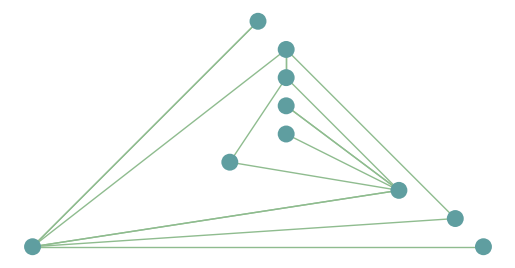

In [567]:
network.plot(bus_sizes=0.001, link_widths=1)

In [568]:
# Guardar resultados en un archivo Excel
network.export_to_excel(
    r"C:\Users\EXT10348\Downloads\WinPython 3.12.10\WPy64-31241\PROYECTOS PYPSA\Dispatching-Project-in-PypSA\Modelo_España_Portugal\Resultados\ES_PT_Unidos.xlsx",
    engine="openpyxl"
)


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\EXT10348\Downloads\WinPython 3.12.10\WPy64-31241\PROYECTOS PYPSA\Dispatching-Project-in-PypSA\Modelo_España_Portugal\Resultados\ES_PT_Unidos.xlsx contains: sub_networks, carriers, storage_units, stores, generators, buses, links, loads


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3706631206.py:6: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3706631206.py:7: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3706631206.py:34: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3706631206.py:36: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



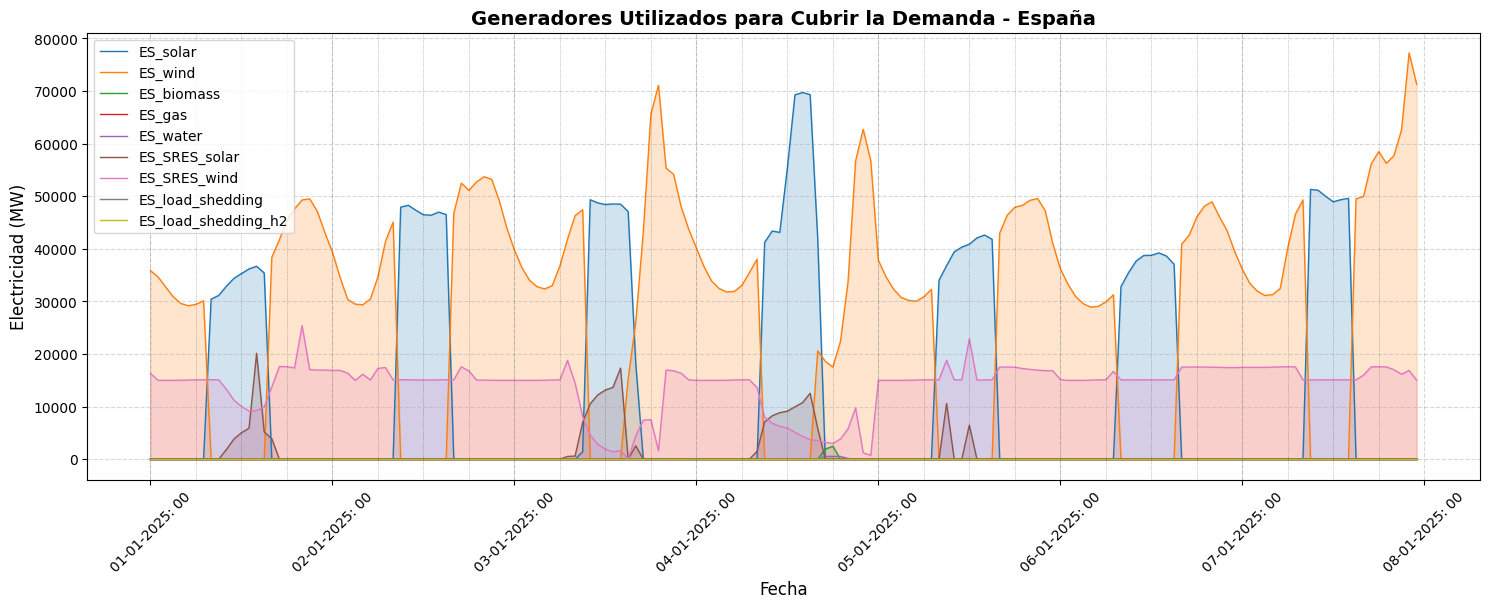

In [569]:

# GENERADORES UTILIZADOS EN ESPAÑA PARA CUBRIR DEMANDA: con este plot podemos graficar la aportación de los generadores sólo de España (sabiendo que los buses de España empiezan por "ES_")
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Para soportar los cambios de versiones de API en PyPSA 
try:
    # API nueva: componentes con .df
    gen_df = network.components["Generator"].df
    buses_df = network.components["Bus"].df
except (AttributeError, KeyError):
    # API clásica: DataFrames directos
    gen_df = network.generators
    buses_df = network.buses
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Definir qué es "España" para los buses ===
# nombre del bus (prefijo ES_)
is_es_bus = buses_df.index.str.startswith("ES_")
# Lista de buses de España
es_buses = set(buses_df.index[is_es_bus])
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Filtrar generadores cuyo 'bus' pertenece a España ===
if "bus" in gen_df.columns:
    generadores_es = gen_df.index[gen_df["bus"].isin(es_buses)]
else:
    # Fallback por nombre si faltara la columna 'bus'
    generadores_es = gen_df.index[gen_df.index.str.startswith("ES_")]
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Rango temporal ===
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h")
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Graficar potencia sólo de generadores de España ===
plt.figure(figsize=(15, 6))
plt.style.use('default')
# En PyPSA, las series temporales de generadores están en network.generators_t.p
# Aseguramos que existan y filtramos por nuestras columnas
cols_disponibles = [g for g in generadores_es if g in network.generators_t.p.columns]
for gen in cols_disponibles:
    y = network.generators_t.p[gen].reindex(hours)  # alinear al rango
    plt.plot(hours, y, label=gen, linewidth=1)
    plt.fill_between(hours, y, color=plt.gca().lines[-1].get_color(), alpha=0.2)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Personalización ===
plt.title("Generadores Utilizados para Cubrir la Demanda - España", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Electricidad (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
# Líneas verticales cada 6 horas
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Comando de graficar
plt.show()
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3886282101.py:13: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3886282101.py:14: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



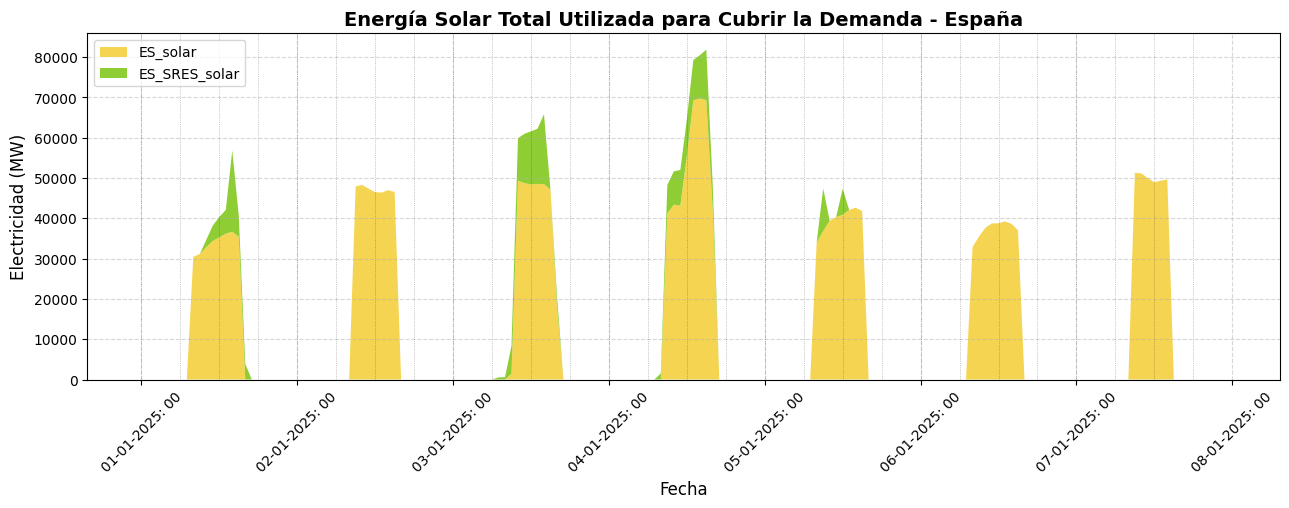

In [570]:
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(13, 5))
plt.style.use('default')
generadores_interes = [
    "ES_solar",
    "ES_SRES_solar",
    
]
series = []
labels = []

for gen in generadores_interes:
    if gen in network.generators_t.p.columns:
        series.append(network.generators_t.p[gen].reindex(hours).values)
        labels.append(gen)

# Stackplot (acumulado)
colors = [
    "#F4D03F",  # amarillo solar suave
    "#82C91E",  # verde natural (excedentes)
    "#4C6EF5",  # azul suave (electrolizador)
]

plt.stackplot(
    hours,
    series,
    labels=labels,
    colors=colors,
    alpha=0.9
)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Personalización ===
plt.title("Energía Solar Total Utilizada para Cubrir la Demanda - España", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Electricidad (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
# Líneas verticales cada 6 horas
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Comando de graficar
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\2039473860.py:13: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\2039473860.py:14: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



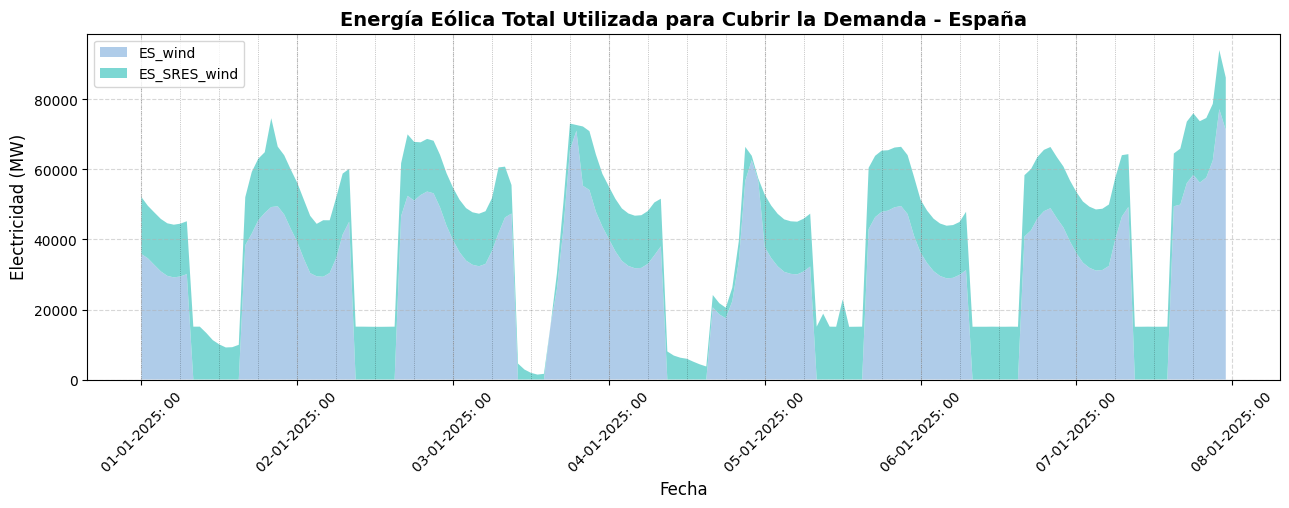

In [571]:
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(13, 5))
plt.style.use('default')
generadores_interes = [
    "ES_wind",
    "ES_SRES_wind",
    
]
series = []
labels = []

for gen in generadores_interes:
    if gen in network.generators_t.p.columns:
        series.append(network.generators_t.p[gen].reindex(hours).values)
        labels.append(gen)

# Stackplot (acumulado)
colors = [
    "#A7C7E7",  # azul cielo (wind)
    "#6ED3CF",  # turquesa suave (excedentes)
    "#2F5D9F",  # azul profundo (electrolizador)
]

plt.stackplot(
    hours,
    series,
    labels=labels,
    colors=colors,
    alpha=0.9
)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Personalización ===
plt.title("Energía Eólica Total Utilizada para Cubrir la Demanda - España", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Electricidad (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
# Líneas verticales cada 6 horas
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Comando de graficar
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3368096690.py:6: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3368096690.py:7: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3368096690.py:33: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3368096690.py:36: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



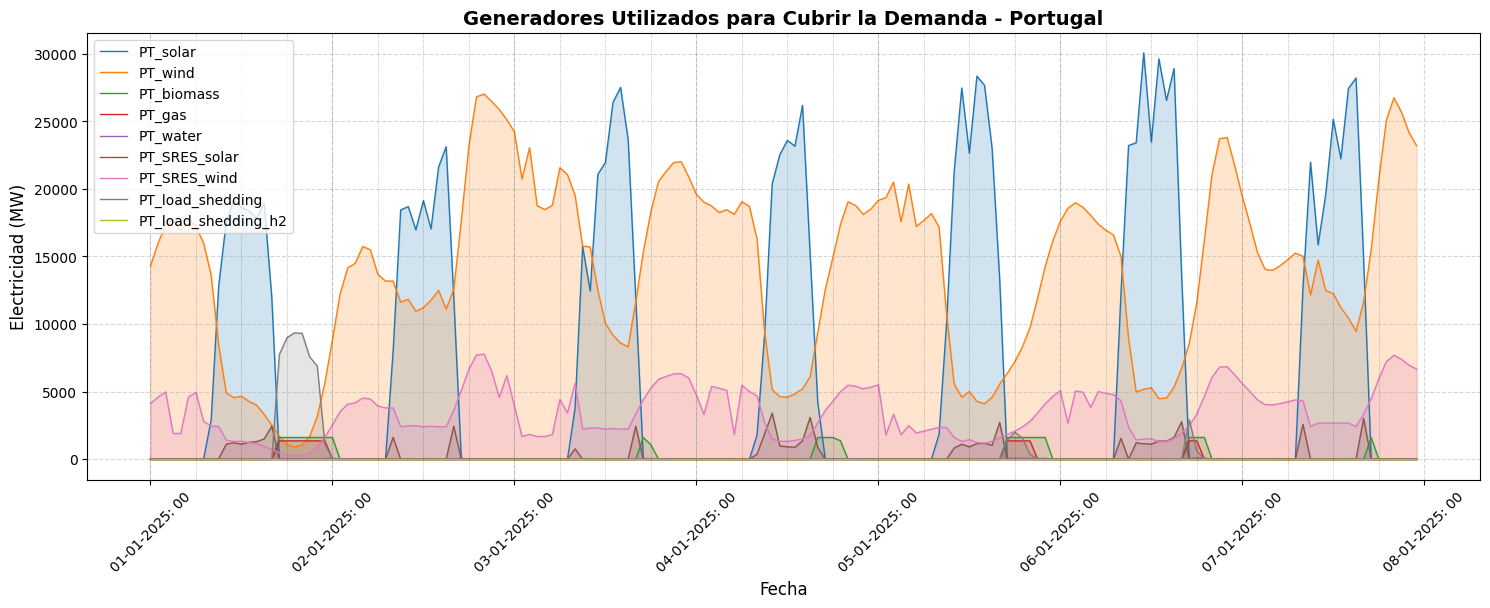

In [572]:
# GENERADORES UTILIZADOS EN PORTUGAL PARA CUBRIR DEMANDA: con este plot podemos graficar la aportación de los generadores sólo de Portugal (sabiendo que los buses de Portugal empiezan por "PT_")
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Obtener DataFrames de generadores y buses (compatibles con varias versiones) ===
try:
    # API nueva (componentes con .df)
    gen_df = network.components["Generator"].df
    buses_df = network.components["Bus"].df
except (AttributeError, KeyError):
    # API clásica (atributos DataFrame)
    gen_df = network.generators
    buses_df = network.buses
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Definir qué es "Portugal" para los buses ===
# Por nombre del bus (prefijo PT_)
is_pt_bus = buses_df.index.str.startswith("PT_")
pt_buses = set(buses_df.index[is_pt_bus])
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Filtrar generadores cuyo 'bus' pertenece a Portugal ===
if "bus" in gen_df.columns:
    generadores_pt = gen_df.index[gen_df["bus"].isin(pt_buses)]
else:
    # Fallback por nombre del generador si no existe la columna 'bus'
    generadores_pt = gen_df.index[gen_df.index.str.startswith("PT_")]
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Rango temporal ===
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h")
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Graficar potencia sólo de generadores de Portugal ===
plt.figure(figsize=(15, 6))
plt.style.use('default')

# Las series temporales están en network.generators_t.p
cols_disponibles = [g for g in generadores_pt if g in network.generators_t.p.columns]

for gen in cols_disponibles:
    y = network.generators_t.p[gen].reindex(hours)  # alinear al rango
    plt.plot(hours, y, label=gen, linewidth=1)
    plt.fill_between(hours, y, color=plt.gca().lines[-1].get_color(), alpha=0.2)
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Personalización ===
plt.title("Generadores Utilizados para Cubrir la Demanda - Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Electricidad (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()

# Líneas verticales cada 6 horas
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)

# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.show()
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\856044811.py:12: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\856044811.py:13: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



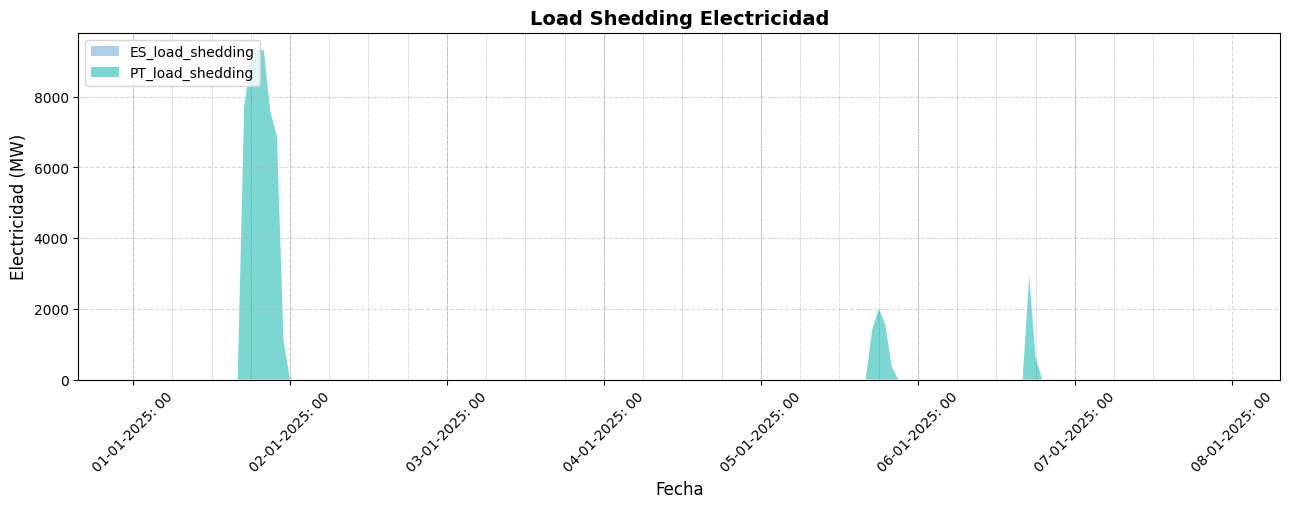

In [573]:
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(13, 5))
plt.style.use('default')
generadores_interes = [
    "ES_load_shedding",  # para ver si hay load shedding en Portugal
    "PT_load_shedding",
]
series = []
labels = []

for gen in generadores_interes:
    if gen in network.generators_t.p.columns:
        series.append(network.generators_t.p[gen].reindex(hours).values)
        labels.append(gen)

# Stackplot (acumulado)
colors = [
    "#A7C7E7",  # azul cielo (wind)
    "#6ED3CF",  # turquesa suave (excedentes)
    "#2F5D9F",  # azul profundo (electrolizador)
]

plt.stackplot(
    hours,
    series,
    labels=labels,
    colors=colors,
    alpha=0.9
)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Personalización ===
plt.title("Load Shedding Electricidad", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Electricidad (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
# Líneas verticales cada 6 horas
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Comando de graficar
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\2695213109.py:12: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\2695213109.py:13: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



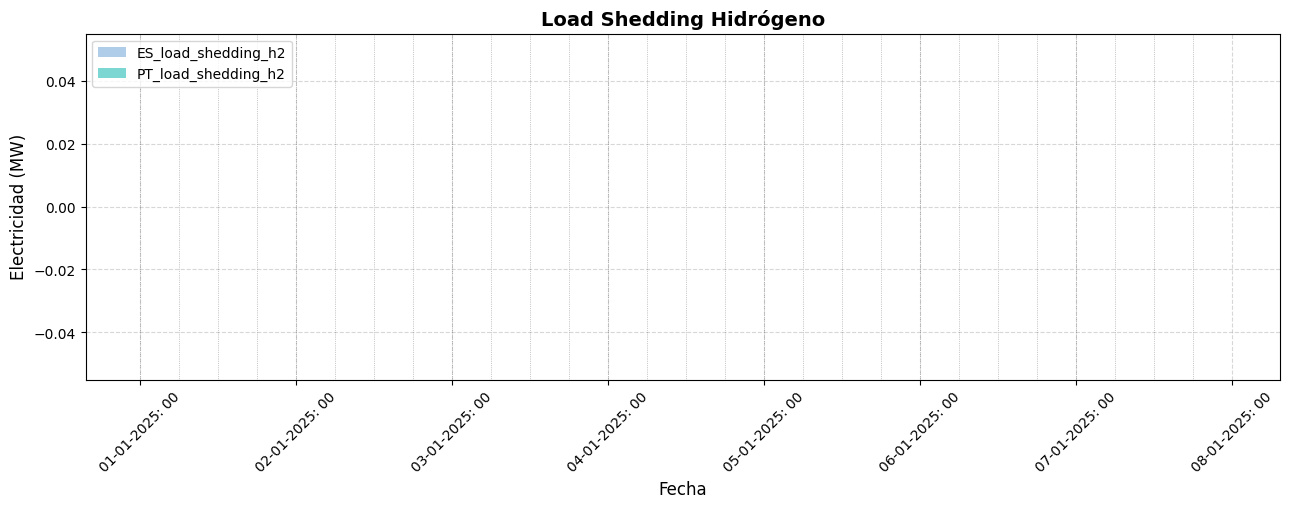

In [574]:
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(13, 5))
plt.style.use('default')
generadores_interes = [
    "ES_load_shedding_h2",  # para ver si hay load shedding en Portugal
    "PT_load_shedding_h2",
]
series = []
labels = []

for gen in generadores_interes:
    if gen in network.generators_t.p.columns:
        series.append(network.generators_t.p[gen].reindex(hours).values)
        labels.append(gen)

# Stackplot (acumulado)
colors = [
    "#A7C7E7",  # azul cielo (wind)
    "#6ED3CF",  # turquesa suave (excedentes)
    "#2F5D9F",  # azul profundo (electrolizador)
]

plt.stackplot(
    hours,
    series,
    labels=labels,
    colors=colors,
    alpha=0.9
)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Personalización ===
plt.title("Load Shedding Hidrógeno", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Electricidad (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
# Líneas verticales cada 6 horas
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Comando de graficar
plt.show()

In [575]:
print("PT demanda max (MW):", network.loads_t.p_set["PT_demand_2040"].max())
print("ES demanda max (MW):", network.loads_t.p_set["ES_demand_2040"].max())

# y el shedding:
names = network.generators.static.index[network.generators.static.carrier=="load_shedding"]
print(network.generators_t.p[names].max())

PT demanda max (MW): 34597.00195694716
ES demanda max (MW): 57703.08642907063
name
ES_load_shedding         -0.000000
PT_load_shedding       9346.474663
ES_load_shedding_h2      -0.000000
PT_load_shedding_h2      -0.000000
dtype: float64


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3006000797.py:1: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3006000797.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3006000797.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\1271761745.py:13: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\1271761745.py:14: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



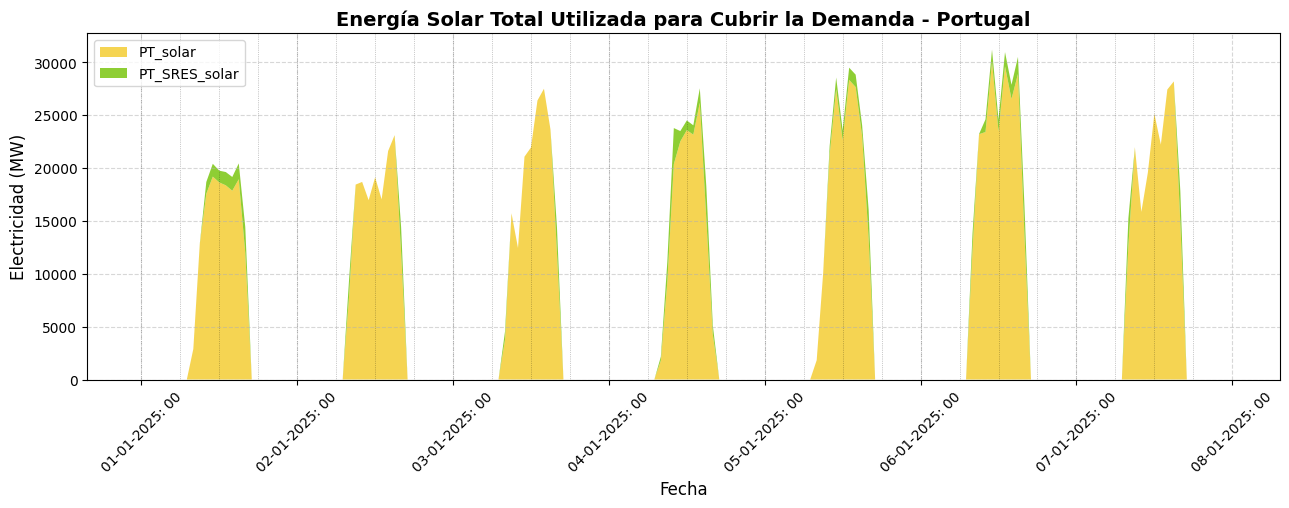

In [576]:
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(13, 5))
plt.style.use('default')
generadores_interes = [
    "PT_solar",
    "PT_SRES_solar",
   
]
series = []
labels = []

for gen in generadores_interes:
    if gen in network.generators_t.p.columns:
        series.append(network.generators_t.p[gen].reindex(hours).values)
        labels.append(gen)

# Stackplot (acumulado)
colors = [
    "#F4D03F",  # amarillo solar suave
    "#82C91E",  # verde natural (excedentes)
    "#4C6EF5",  # azul suave (electrolizador)
]

plt.stackplot(
    hours,
    series,
    labels=labels,
    colors=colors,
    alpha=0.9
)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Personalización ===
plt.title("Energía Solar Total Utilizada para Cubrir la Demanda - Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Electricidad (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
# Líneas verticales cada 6 horas
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Comando de graficar
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3348319044.py:13: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3348319044.py:14: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



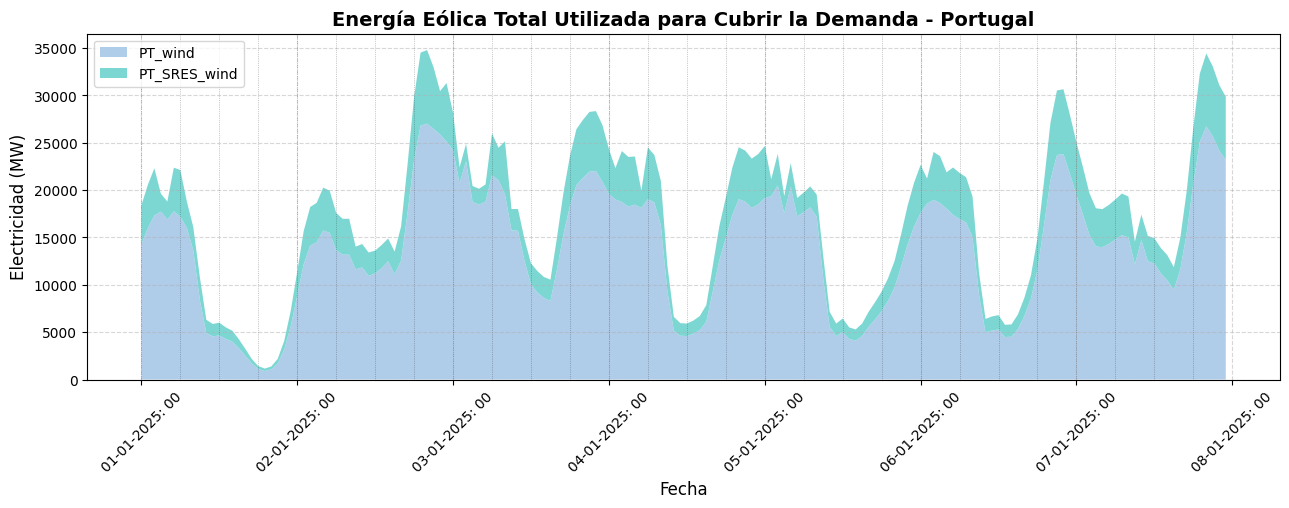

In [577]:
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(13, 5))
plt.style.use('default')
generadores_interes = [
    "PT_wind",
 
    "PT_SRES_wind"
]
series = []
labels = []

for gen in generadores_interes:
    if gen in network.generators_t.p.columns:
        series.append(network.generators_t.p[gen].reindex(hours).values)
        labels.append(gen)

# Stackplot (acumulado)
colors = [
    "#A7C7E7",  # azul cielo (wind)
    "#6ED3CF",  # turquesa suave (excedentes)
    "#2F5D9F",  # azul profundo (electrolizador)
]

plt.stackplot(
    hours,
    series,
    labels=labels,
    colors=colors,
    alpha=0.9
)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Personalización ===
plt.title("Energía Eólica Total Utilizada para Cubrir la Demanda - Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Electricidad (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
# Líneas verticales cada 6 horas
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Comando de graficar
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3175466517.py:1: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



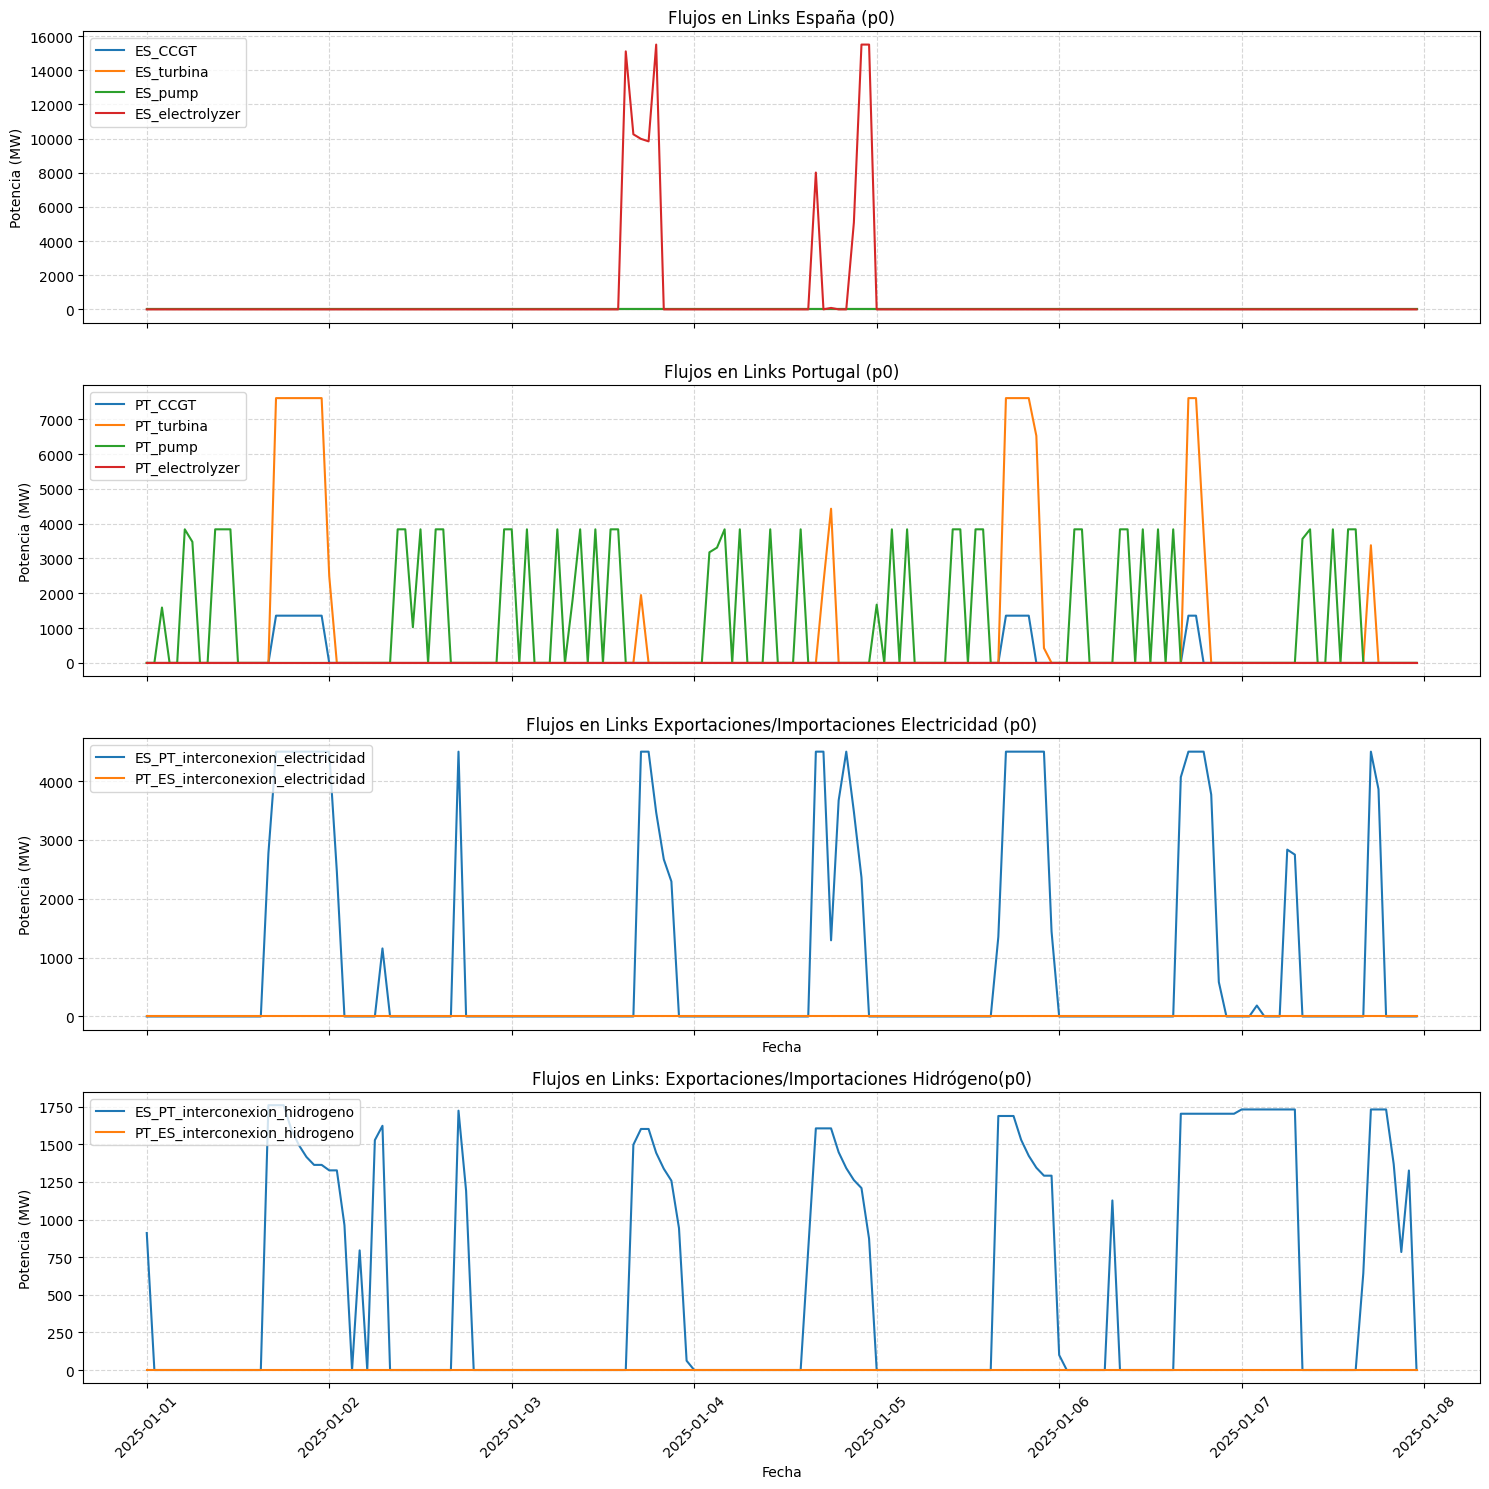

In [578]:
p0 = network.links_t.p0
links_ES = [
    "ES_CCGT",
    "ES_turbina",
    "ES_pump",
    "ES_electrolyzer",
]

links_PT = [
    "PT_CCGT",
    "PT_turbina",
    "PT_pump",
    "PT_electrolyzer",
]

links_exportaciones_electricidad = [
    "ES_PT_interconexion_electricidad",
    "PT_ES_interconexion_electricidad",
]

links_exportaciones_hidrogeno = [
    "ES_PT_interconexion_hidrogeno",
    "PT_ES_interconexion_hidrogeno",
]

# --- Crear figura con 4 subplots ---
fig, axes = plt.subplots(4, 1, figsize=(15, 15), sharex=True)  # 3 filas, 1 columna
 
# --- GRAFICO ESPAÑA ---
for link in links_ES:
    if link in p0.columns:
        axes[0].plot(network.snapshots, p0[link], label=link)
axes[0].set_title("Flujos en Links España (p0)")
axes[0].set_ylabel("Potencia (MW)")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(loc="upper left")
 
# --- GRAFICO PORTUGAL ---
for link in links_PT:
    if link in p0.columns:
        axes[1].plot(network.snapshots, p0[link], label=link)
axes[1].set_title("Flujos en Links Portugal (p0)")
axes[1].set_ylabel("Potencia (MW)")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="upper left")
 
# --- GRAFICO EXPORTACIONES electricidad ---
for link in links_exportaciones_electricidad:
    if link in p0.columns:
        axes[2].plot(network.snapshots, p0[link], label=link)
axes[2].set_title("Flujos en Links Exportaciones/Importaciones Electricidad (p0)")
axes[2].set_xlabel("Fecha")
axes[2].set_ylabel("Potencia (MW)")
axes[2].grid(True, linestyle="--", alpha=0.5)
axes[2].legend(loc="upper left")

 

# --- GRAFICO EXPORTACIONES hidrogeno---
for link in links_exportaciones_hidrogeno:
    if link in p0.columns:
        axes[3].plot(network.snapshots, p0[link], label=link)
axes[3].set_title("Flujos en Links: Exportaciones/Importaciones Hidrógeno(p0)")
axes[3].set_xlabel("Fecha")
axes[3].set_ylabel("Potencia (MW)")
axes[3].grid(True, linestyle="--", alpha=0.5)
axes[3].legend(loc="upper left")

# Ajustar diseño
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
 

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\941454363.py:1: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



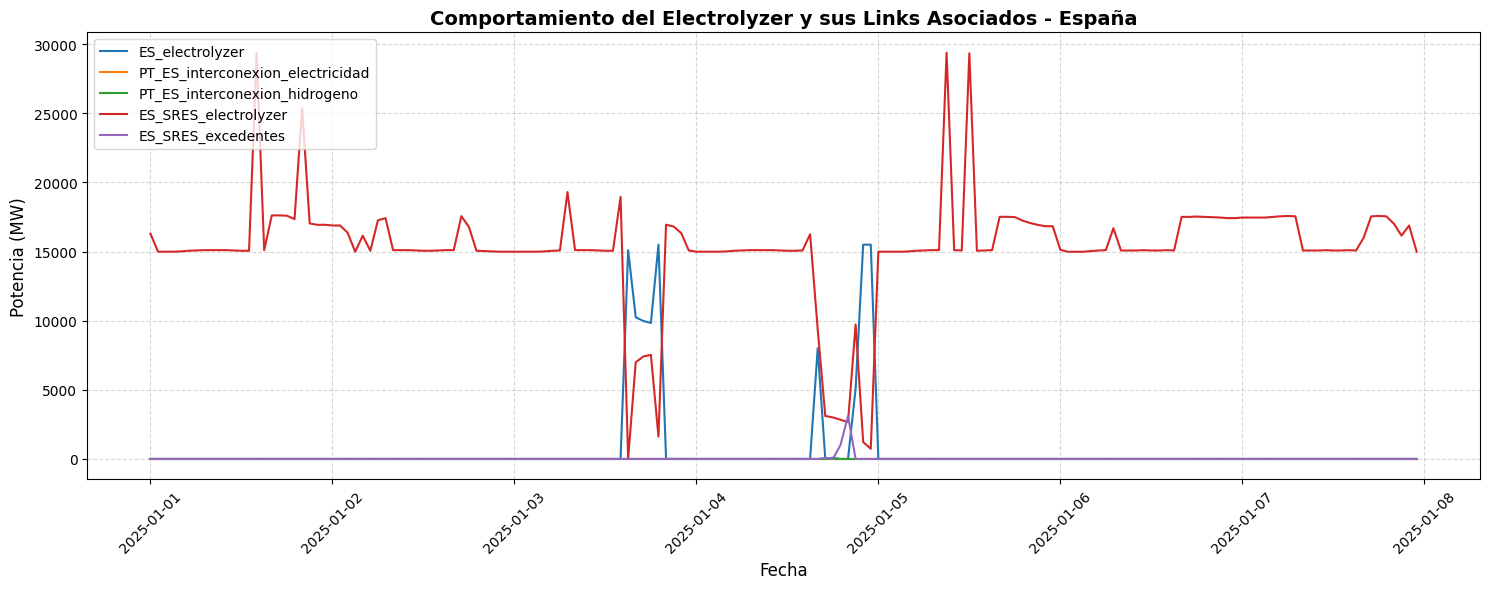

In [579]:
p0 = network.links_t.p0
comportamiento_electrolyzer = [
    "ES_electrolyzer",
    "PT_ES_interconexion_electricidad",
    "PT_ES_interconexion_hidrogeno",
    "ES_SRES_electrolyzer",
    "ES_SRES_excedentes"

]


# haz una grafica donde estén los links relacionados con el comportamiento del electrolyzer en España y Portugal
plt.figure(figsize=(15,6))
for link in comportamiento_electrolyzer:
    if link in p0.columns:
        plt.plot(network.snapshots, p0[link], label=link)
plt.title("Comportamiento del Electrolyzer y sus Links Asociados - España", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Potencia (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\1188415387.py:1: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



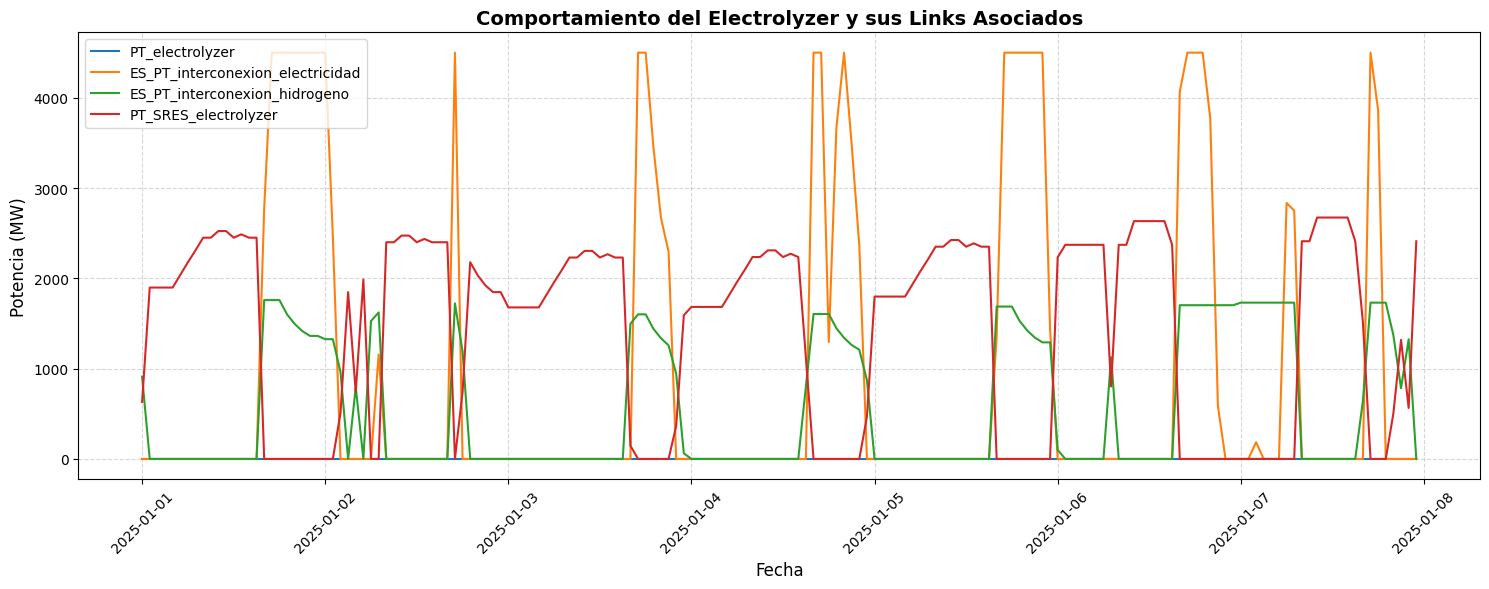

In [580]:
p0 = network.links_t.p0
comportamiento_electrolyzer = [
    "PT_electrolyzer",
    "ES_PT_interconexion_electricidad",
    "ES_PT_interconexion_hidrogeno",
    "PT_SRES_electrolyzer"

]


# haz una grafica donde estén los links relacionados con el comportamiento del electrolyzer en España y Portugal
plt.figure(figsize=(15,6))
for link in comportamiento_electrolyzer:
    if link in p0.columns:
        plt.plot(network.snapshots, p0[link], label=link)
plt.title("Comportamiento del Electrolyzer y sus Links Asociados", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Potencia (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()


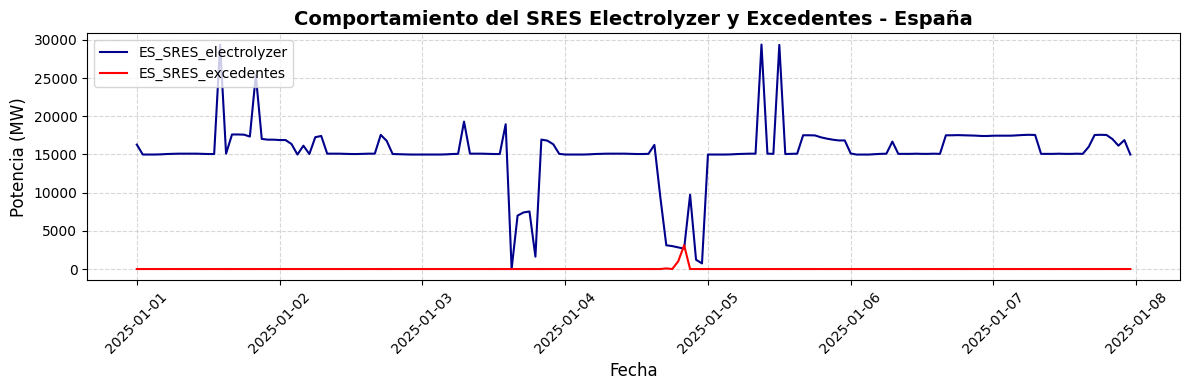

In [581]:
#  HAZ UN GRAFICA DE LOS LINKS ES_SRES_electrolyzer y ES_SRES_excedentes
plt.figure(figsize=(12,4))
links_sres = [
    "ES_SRES_electrolyzer",
    "ES_SRES_excedentes"
]
for link in links_sres:
    if link in p0.columns:
        
        if link == "ES_SRES_electrolyzer":
            plt.plot(network.snapshots, p0[link], label=link, color="darkblue")
        elif link == "ES_SRES_excedentes":
            plt.plot(network.snapshots, p0[link], label=link, color="red")
        plt.title("Comportamiento del SRES Electrolyzer y Excedentes - España", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Potencia (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()



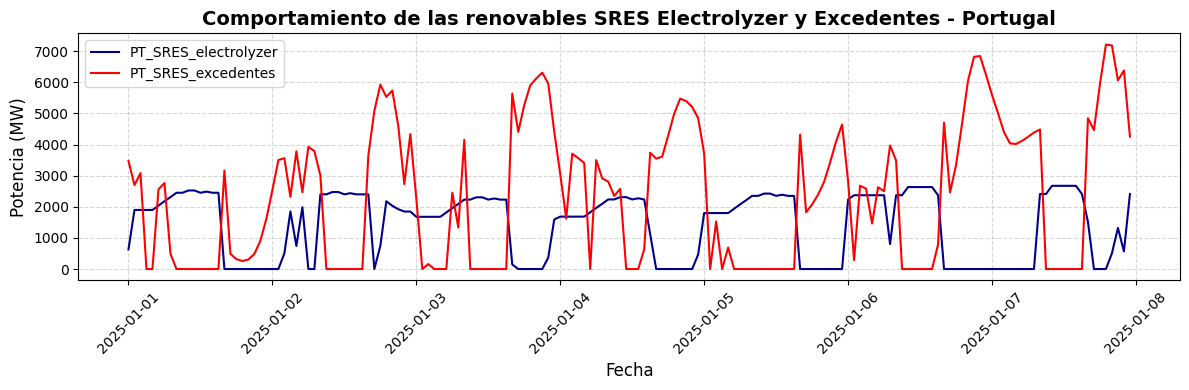

In [582]:
#  HAZ UN GRAFICA DE LOS LINKS ES_SRES_electrolyzer y ES_SRES_excedentes
plt.figure(figsize=(12,4))
links_sres = [
    "PT_SRES_electrolyzer",
    "PT_SRES_excedentes"
]
for link in links_sres:
    if link in p0.columns:

        if link == "PT_SRES_electrolyzer":
            plt.plot(network.snapshots, p0[link], label=link, color="darkblue")
        elif link == "PT_SRES_excedentes":
            plt.plot(network.snapshots, p0[link], label=link, color="red")
            # RECUERDA ESTO ES P0 ESTAS MIRANDO ELECTTRICIDAD
        plt.title("Comportamiento de las renovables SRES Electrolyzer y Excedentes - Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Potencia (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

In [583]:
Gt_max = 12589 + 9922
C_electr = 13478
max_ex = max(0.0, Gt_max - C_electr)

link_ex = "PT_SRES_excedentes"
PT_SRES_bus = "PT_SRES_bus"   # cambia si tu bus se llama distinto

# mirar buses del link (API nueva)
b0 = network.links.static.at[link_ex, "bus0"]
b1 = network.links.static.at[link_ex, "bus1"]

# flujo saliendo del bus SRES (con signo correcto)
if b0 == PT_SRES_bus:
    ex = network.links_t.p0[link_ex]
elif b1 == PT_SRES_bus:
    ex = -network.links_t.p1[link_ex]
else:
    raise ValueError(f"El link {link_ex} no conecta con el bus {PT_SRES_bus}: bus0={b0}, bus1={b1}")

# por si hay ruido numérico
ex = ex.clip(lower=0.0)

viol = ex[ex > max_ex + 1e-6]

print("Max permitido:", max_ex)
print("Max observado:", float(ex.max()))
print("Violaciones:", int(viol.size))
if viol.size:
    print("Primeras violaciones:")
    print(viol.head())


Max permitido: 9033
Max observado: 7213.294
Violaciones: 0


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3284428418.py:14: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



In [584]:
# HAY HORAS DONDE EL ELECTROLIZADOR NO ESTÁ UTILIZANDOSE AL MÁXIMO, SIN CUBRIR LA DEMANDA DE H2, 
# Y EXCEDENTES FUNCIONANDO?
p_ex = network.links_t.p0["PT_SRES_excedentes"].clip(lower=0.0)
p_el = network.links_t.p0["PT_SRES_electrolyzer"].clip(lower=0.0)
cap_el = float(network.links.static.at["PT_SRES_electrolyzer", "p_nom"])

h2_demand = network.loads_t.p["PT_hydrogen_demand"]

mask = (p_ex > 1e-3) & (p_el < cap_el - 1e-3) & (h2_demand > p_el + 1e-3)

print("Horas con excedentes>0, electrolizador con margen, y demanda H2 > producción:", int(mask.sum()))
if mask.sum():
    print(pd.DataFrame({
        "excedentes_MW": p_ex[mask],
        "electrolizador_MW": p_el[mask],
        "demanda_H2_MW": h2_demand[mask],
        "cap_el_MW": cap_el
    }).head())


Horas con excedentes>0, electrolizador con margen, y demanda H2 > producción: 65
                     excedentes_MW  electrolizador_MW  demanda_H2_MW  \
snapshot                                                               
2025-01-01 00:00:00    3477.545861         630.162139    1328.747032   
2025-01-01 16:00:00    3165.776600          -0.000000    1715.417333   
2025-01-01 17:00:00     486.178000          -0.000000    1715.417333   
2025-01-01 18:00:00     317.504000          -0.000000    1715.417333   
2025-01-01 19:00:00     257.972000          -0.000000    1560.749213   

                     cap_el_MW  
snapshot                        
2025-01-01 00:00:00    13478.0  
2025-01-01 16:00:00    13478.0  
2025-01-01 17:00:00    13478.0  
2025-01-01 18:00:00    13478.0  
2025-01-01 19:00:00    13478.0  


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\1345572685.py:3: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\1345572685.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\1345572685.py:7: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.



In [585]:
SRES_BUS = "PT_SRES_bus"
link_el = "PT_SRES_electrolyzer"
link_ex = "PT_SRES_excedentes"

# flujos saliendo del SRES (asumiendo bus0 = PT_SRES_bus, que en tu tabla sí lo es)
p_el = network.links_t.p0[link_el].clip(lower=0.0)
p_ex = network.links_t.p0[link_ex].clip(lower=0.0)

cap_el = float(network.links.static.at[link_el, "p_nom"])

mask = (p_ex > 1e-3) & (p_el < cap_el - 1e-3)

print("Horas con excedentes>0 y electrolizador NO saturado:", int(mask.sum()))
if mask.sum():
    print("Ejemplo (primeras horas):")
    print(
        (p_ex[mask].rename("excedentes_MW")
         .to_frame()
         .assign(electrolizador_MW=p_el[mask], cap_el_MW=cap_el))
        .head()
    )


Horas con excedentes>0 y electrolizador NO saturado: 110
Ejemplo (primeras horas):
                     excedentes_MW  electrolizador_MW  cap_el_MW
snapshot                                                        
2025-01-01 00:00:00    3477.545861         630.162139    13478.0
2025-01-01 01:00:00    2695.675954        1898.210046    13478.0
2025-01-01 02:00:00    3082.633954        1898.210046    13478.0
2025-01-01 05:00:00    2559.263996        2038.147869    13478.0
2025-01-01 06:00:00    2763.070307        2178.085693    13478.0


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\1325518510.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\1325518510.py:7: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



In [586]:
h2_bus = network.links.static.at[link_el, "bus1"]
print("H2 bus:", h2_bus)

print("Loads en H2:", network.loads.static.index[network.loads.static.bus == h2_bus].tolist())
print("Stores en H2:", network.stores.static.index[network.stores.static.bus == h2_bus].tolist())
print("StorageUnits en H2:", network.storage_units.static.index[network.storage_units.static.bus == h2_bus].tolist())
print("Links que salen de H2:", network.links.static.index[network.links.static.bus0 == h2_bus].tolist())


H2 bus: PT_hydrogen_bus
Loads en H2: ['PT_hydrogen_demand']
Stores en H2: []
StorageUnits en H2: []
Links que salen de H2: ['PT_ES_interconexion_hidrogeno']


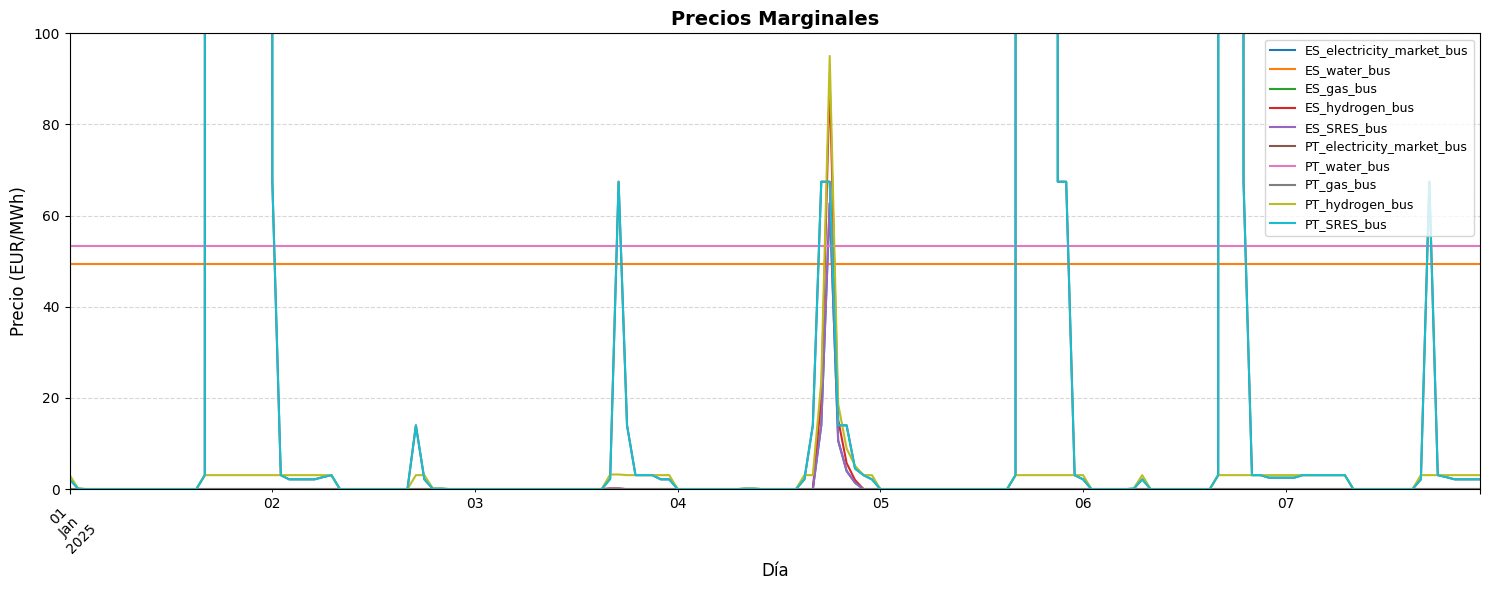

In [587]:
# PRECIOS MARGINALES con API moderna. 
# MIRAR SI PONER LINKS EN VEZ DE BUSES
network.buses.dynamic["marginal_price"].plot(figsize=(15,6), title="Precios Marginales")

# Personalización
plt.title("Precios Marginales", fontsize=14, fontweight="bold")
plt.xlabel("Día", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right", fontsize=9)
plt.ylim(0,100)  # empezar eje Y en 0

plt.tight_layout()
plt.show()

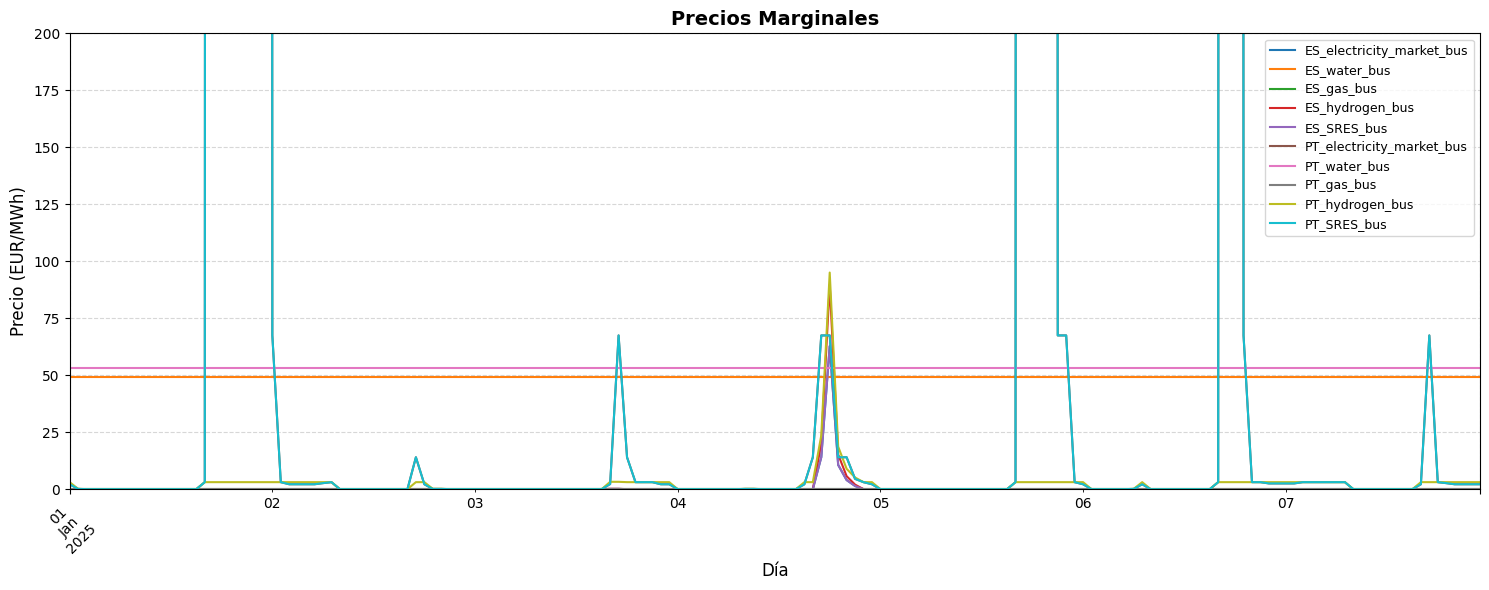

In [588]:
# PRECIOS MARGINALES con API moderna
network.buses.dynamic["marginal_price"].plot(figsize=(15,6), title="Precios Marginales")

# Personalización
plt.title("Precios Marginales", fontsize=14, fontweight="bold")
plt.xlabel("Día", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right", fontsize=9)

plt.ylim(0, 200)  # Ajusta el límite del eje Y según sea necesario
plt.tight_layout()
plt.show()

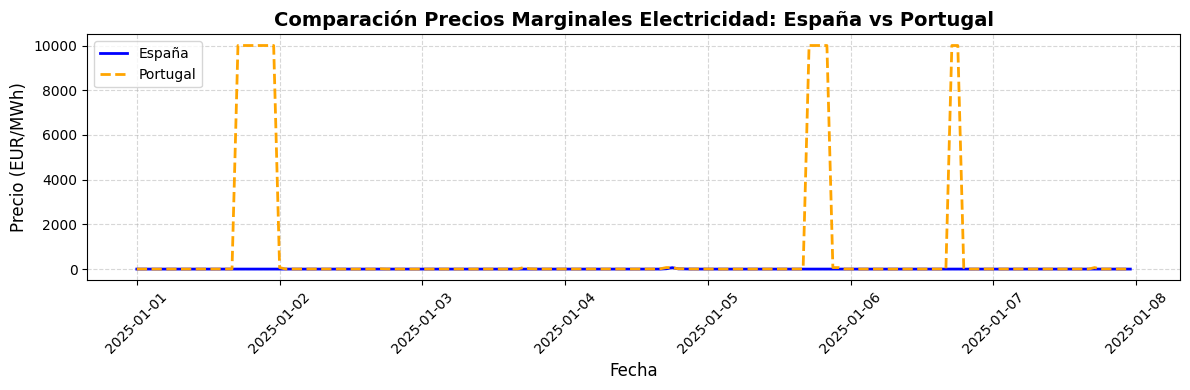

In [589]:

# Filtrar precios marginales para buses eléctricos
marginal_prices = network.buses.dynamic["marginal_price"]

# Seleccionar columnas específicas
cols_electricity = ["ES_electricity_market_bus", "PT_electricity_market_bus"]

# Verificar que existen en el DataFrame
available_cols = [col for col in cols_electricity if col in marginal_prices.columns]

# Graficar con estilos diferentes
plt.figure(figsize=(12,4))

if "ES_electricity_market_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["ES_electricity_market_bus"],
             label="España", color="blue", linestyle="-", linewidth=2)  # Línea continua

if "PT_electricity_market_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["PT_electricity_market_bus"],
             label="Portugal", color="orange", linestyle="--", linewidth=2)  # Línea discontinua

# Personalización
plt.title("Comparación Precios Marginales Electricidad: España vs Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

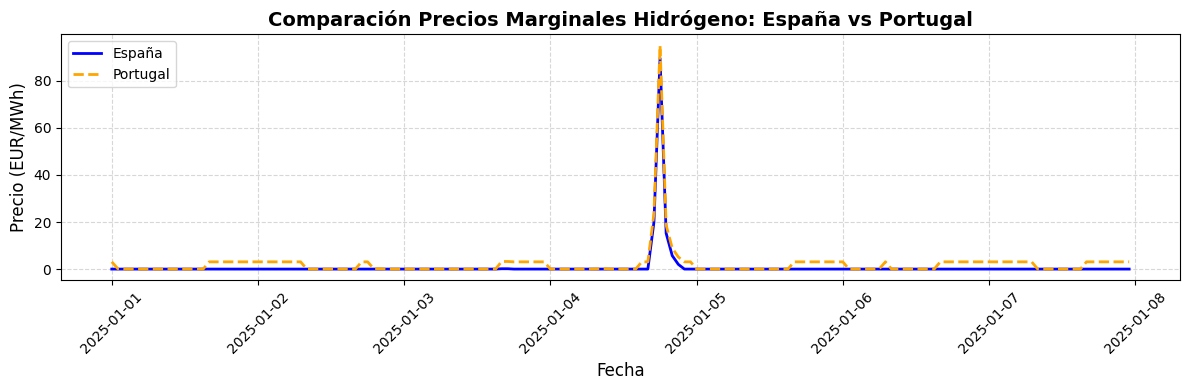

In [590]:
# Filtrar precios marginales para buses eléctricos
marginal_prices = network.buses.dynamic["marginal_price"]

# Seleccionar columnas específicas
cols_electricity = ["ES_hydrogen_bus", "PT_hydrogen_bus"]

# Verificar que existen en el DataFrame
available_cols = [col for col in cols_electricity if col in marginal_prices.columns]

# Graficar con estilos diferentes
plt.figure(figsize=(12,4))

if "ES_hydrogen_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["ES_hydrogen_bus"],
             label="España", color="blue", linestyle="-", linewidth=2)  # Línea continua

if "PT_hydrogen_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["PT_hydrogen_bus"],
             label="Portugal", color="orange", linestyle="--", linewidth=2)  # Línea discontinua

# Personalización
plt.title("Comparación Precios Marginales Hidrógeno: España vs Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\1122075521.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\1122075521.py:29: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\1122075521.py:38: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\1122075521.py:41: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dyn

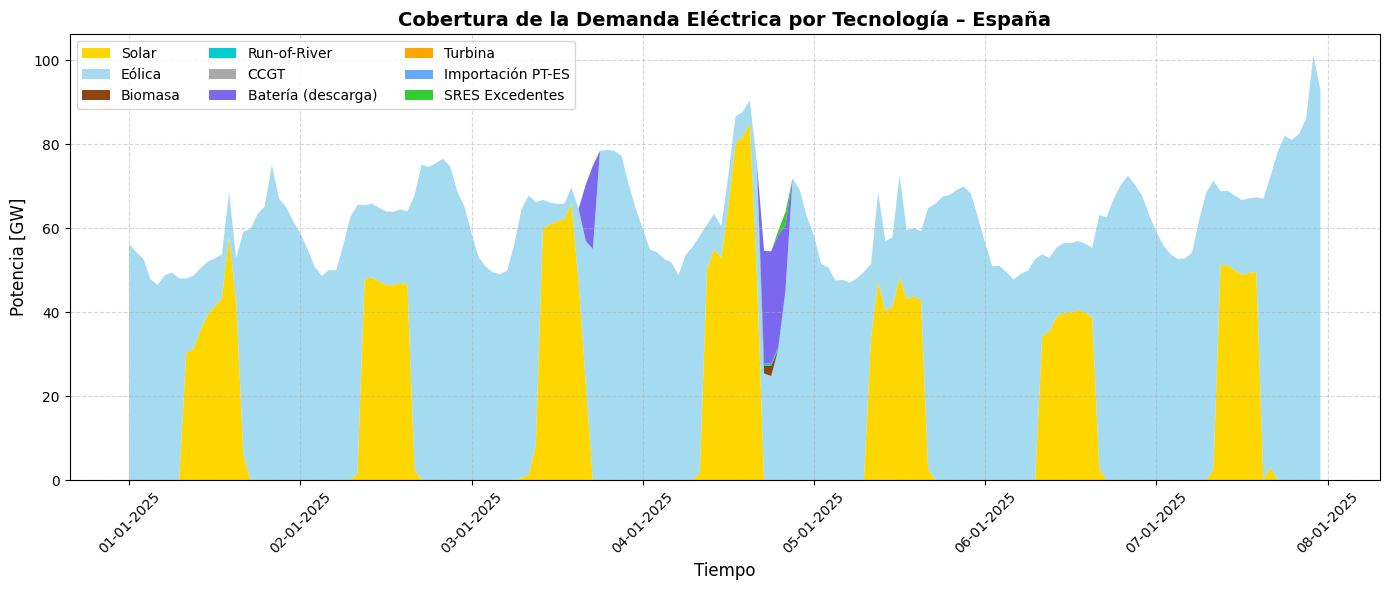

In [591]:
times = network.snapshots
gen = network.generators_t.p
gen_names = gen.columns.str.lower()
renew_map = {
    "ES_Solar":   "es_solar",  
    "ES_Eólica":  "es_wind",
    "ES_Biomasa": "es_biomass",
    "ES_Water":   "es_water",
}
renew_series = {}
for label, key in renew_map.items():
    gens = gen.columns[gen_names.str.contains(key)]
    if len(gens) == 0:
        print(f"No se encontraron generadores con '{key}'")
        renew_series[label] = 0.0
    else:
        renew_series[label] = gen[gens].sum(axis=1)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# LINKS UTILIZADOS EN ESPAÑA PARA CUBRIR DEMANDA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
links_car = network.links.static.index.str.lower()
# Link 1 que genera electricidad: CCGT
ccgt_name = [
    n for n in network.links.static.index
    if "es_ccgt" in n.lower()
]
if len(ccgt_name) == 0:
    print("No se encontró ningún link con 'CCGT'")
CCGT = -network.links_t.p1[ccgt_name].sum(axis=1).clip(upper=0)

# Link 2 que genera electricidad: TURBINA
turb_name = [
    n for n in network.links.static.index
    if "es_turbina" in n.lower()
]
if len(turb_name) == 0:
    print("No se encontró ningún link con 'turbina'")
turb = -network.links_t.p1[turb_name].sum(axis=1).clip(upper=0)

# Link 3 que genera electricidad: Importacion PT-ES Eléctricidad
import_es_pt = network.links_t.p1["PT_ES_interconexion_electricidad"].clip(upper=0)

# Link 4: sres_excedentes (excedentes renovables)
sres_excedentes_name = [
    n for n in network.links.static.index
    if "es_sres_excedentes" in n.lower()
]
if len(sres_excedentes_name) == 0:
    print("No se encontró ningún link con 'es_sres_excedentes'")
sres_excedentes = -network.links_t.p1[sres_excedentes_name].sum(axis=1).clip(upper=0)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# STORAGE UNITS: BATERÍAS ELECTRICIDAD Y ALMACENAMIENTO DE HIDRÓGENO
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

su_names = network.storage_units.static.index.str.lower()

battery_sus = [n for n in network.storage_units.static.index if "es_electricity_market_battery" in n.lower()]
h2_sus      = [n for n in network.storage_units.static.index if "es_hydrogen_storage" in n.lower()]

# 6) Potencia neta
bat_net = network.storage_units_t.p[battery_sus].sum(axis=1)
h2_net  = network.storage_units_t.p[h2_sus].sum(axis=1)

battery_discharge = bat_net.clip(lower=0)
h2_discharge = h2_net.clip(lower=0)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# DATAFRAME PARA GRÁFICA DE COBERTURA DE DEMANDA EN ESPAÑA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


df_plot = pd.DataFrame({
    "ES_Solar":         renew_series["ES_Solar"]     / 1e3,
    "ES_Eólica":        renew_series["ES_Eólica"]      / 1e3,
    "ES_Biomasa":       renew_series["ES_Biomasa"]   / 1e3,
    "ES_Run-of-River":  renew_series["ES_Water"]     / 1e3,
    "ES_CCGT":          CCGT                      / 1e3,
    "ES_electricity_market_battery":      battery_discharge         / 1e3,
    "ES_turbina":       turb                      / 1e3,
    "PT_ES_interconexion_electricidad": import_es_pt / 1e3,
    "ES_sres_excedentes": sres_excedentes / 1e3,
}, index=times)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# COLORES PARA GRÁFICA Y TECNOLOGÍA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

colors = {
    "ES_Solar":                           "#FFD700",
    "ES_Eólica":                          "#87CFEBBE",
    "ES_Biomasa":                         "#8B4513",
    "ES_Run-of-River":                    "#00CED1",
    "ES_CCGT":                            "#A9A9A9",
    "ES_electricity_market_battery":      "#7B68EE",
    "ES_turbina":                         "#FFA500",
    "ES_sres_excedentes":               "#32CD32",
    "PT_ES_interconexion_electricidad":   "#2386F7B2",
}

c = [colors[col] for col in df_plot.columns]

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# PERSONALIZACIÓN DE LA GRÁFICA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

plt.figure(figsize=(14, 6))
plt.stackplot(
    df_plot.index,
    df_plot["ES_Solar"], df_plot["ES_Eólica"], df_plot["ES_Biomasa"], df_plot["ES_Run-of-River"], df_plot["ES_CCGT"], df_plot["ES_electricity_market_battery"], df_plot["ES_turbina"], df_plot["PT_ES_interconexion_electricidad"],df_plot["ES_sres_excedentes"],
    labels=["Solar","Eólica","Biomasa","Run-of-River","CCGT","Batería (descarga)","Turbina","Importación PT-ES", "SRES Excedentes"],
    colors=[colors["ES_Solar"],colors["ES_Eólica"],colors["ES_Biomasa"],colors["ES_Run-of-River"],colors["ES_CCGT"],colors["ES_electricity_market_battery"],colors["ES_turbina"],colors["PT_ES_interconexion_electricidad"], colors["ES_sres_excedentes"]],
    linewidth=0.0,
)
plt.title("Cobertura de la Demanda Eléctrica por Tecnología – España",fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10, ncol=3)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\301567258.py:3: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\301567258.py:31: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\301567258.py:40: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\301567258.py:43: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic

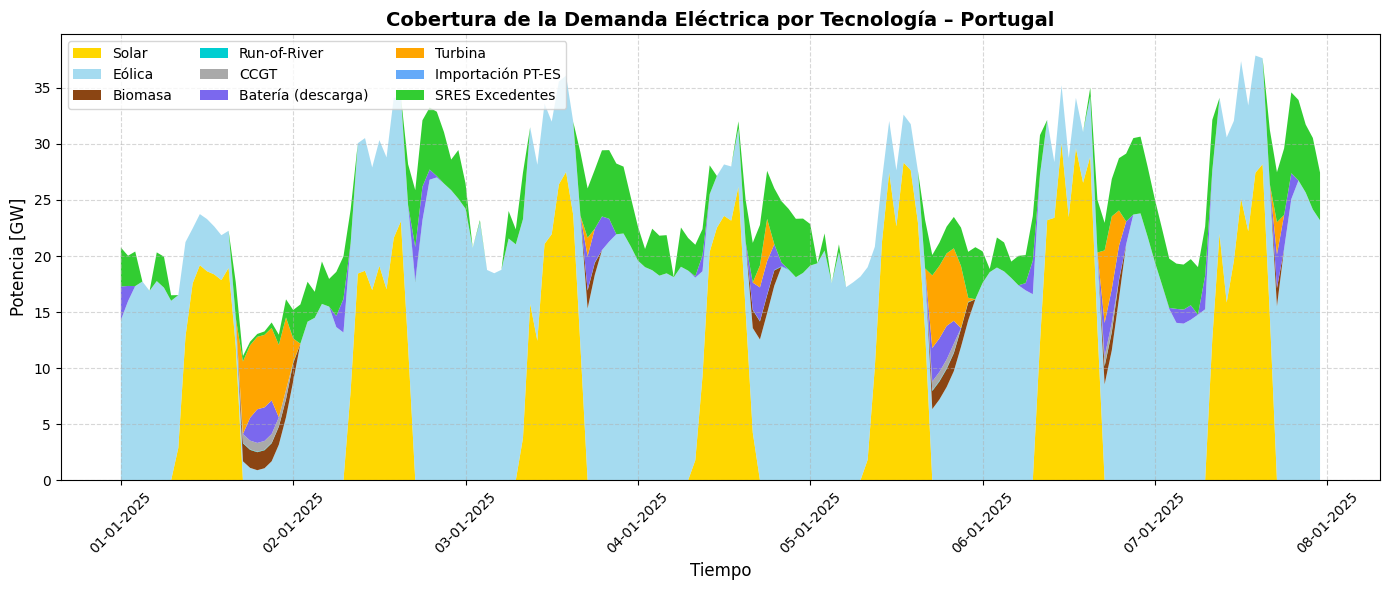

In [592]:
# PORTUGAL. OJO PONER LOAD SHEDDING
times = network.snapshots
gen = network.generators_t.p
gen_names = gen.columns.str.lower()
renew_map = {
    "PT_Solar":   "pt_solar",  
    "PT_Eólica":  "pt_wind",
    "PT_Biomasa": "pt_biomass",
    "PT_Water":   "pt_water",
   # "PT_Load_shedding": "pt_load_shedding"
}
renew_series = {}
for label, key in renew_map.items():
    gens = gen.columns[gen_names.str.contains(key)]
    if len(gens) == 0:
        print(f"No se encontraron generadores con '{key}'")
        renew_series[label] = 0.0
    else:
        renew_series[label] = gen[gens].sum(axis=1)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# LINKS UTILIZADOS EN ESPAÑA PARA CUBRIR DEMANDA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
links_car = network.links.static.index.str.lower()
# Link 1 que genera electricidad: CCGT
ccgt_name = [
    n for n in network.links.static.index
    if "pt_ccgt" in n.lower()
]
if len(ccgt_name) == 0:
    print("No se encontró ningún link con 'CCGT'")
CCGT = -network.links_t.p1[ccgt_name].sum(axis=1).clip(upper=0)

# Link 2 que genera electricidad: TURBINA
turb_name = [
    n for n in network.links.static.index
    if "pt_turbina" in n.lower()
]
if len(turb_name) == 0:
    print("No se encontró ningún link con 'turbina'")
turb = -network.links_t.p1[turb_name].sum(axis=1).clip(upper=0)

# Link 3 que genera electricidad: Importacion ES-PT Eléctricidad
import_pt_es = network.links_t.p1["ES_PT_interconexion_electricidad"].clip(upper=0)



# Link 4: sres_excedentes (excedentes renovables)
sres_excedentes_name = [
    n for n in network.links.static.index
    if "pt_sres_excedentes" in n.lower()
]
if len(sres_excedentes_name) == 0:
    print("No se encontró ningún link con 'pt_sres_excedentes'")
sres_excedentes = -network.links_t.p1[sres_excedentes_name].sum(axis=1).clip(upper=0)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# STORAGE UNITS: BATERÍAS ELECTRICIDAD Y ALMACENAMIENTO DE HIDRÓGENO
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

su_names = network.storage_units.static.index.str.lower()

battery_sus = [n for n in network.storage_units.static.index if "pt_electricity_market_battery" in n.lower()]
h2_sus      = [n for n in network.storage_units.static.index if "pt_hydrogen_storage" in n.lower()]

# 6) Potencia neta
bat_net = network.storage_units_t.p[battery_sus].sum(axis=1)
h2_net  = network.storage_units_t.p[h2_sus].sum(axis=1)

battery_discharge = bat_net.clip(lower=0)
h2_discharge = h2_net.clip(lower=0)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# DATAFRAME PARA GRÁFICA DE COBERTURA DE DEMANDA EN ESPAÑA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


df_plot = pd.DataFrame({
    "PT_Solar":         renew_series["PT_Solar"]     / 1e3,
    "PT_Eólica":        renew_series["PT_Eólica"]      / 1e3,
    "PT_Biomasa":       renew_series["PT_Biomasa"]   / 1e3,
    "PT_Run-of-River":  renew_series["PT_Water"]     / 1e3,
    "PT_CCGT":          CCGT                      / 1e3,
    "PT_electricity_market_battery":      battery_discharge         / 1e3,
    "PT_turbina":       turb                      / 1e3,
    "ES_PT_interconexion_electricidad": import_es_pt / 1e3,
    "PT_sres_excedentes": sres_excedentes / 1e3,
    
}, index=times)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# COLORES PARA GRÁFICA Y TECNOLOGÍA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

colors = {
    "PT_Solar":                           "#FFD700",
    "PT_Eólica":                          "#87CFEBBE",
    "PT_Biomasa":                         "#8B4513",
    "PT_Run-of-River":                    "#00CED1",
    "PT_CCGT":                            "#A9A9A9",
    "PT_electricity_market_battery":      "#7B68EE",
    "PT_turbina":                         "#FFA500",
    "PT_sres_excedentes":               "#32CD32",
    "ES_PT_interconexion_electricidad":   "#2386F7B2",
    "ES_load_shedding":                   "#FF0000",
}

c = [colors[col] for col in df_plot.columns]

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# PERSONALIZACIÓN DE LA GRÁFICA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

plt.figure(figsize=(14, 6))
plt.stackplot(
    df_plot.index,
    df_plot["PT_Solar"], df_plot["PT_Eólica"], df_plot["PT_Biomasa"], df_plot["PT_Run-of-River"], df_plot["PT_CCGT"], df_plot["PT_electricity_market_battery"], df_plot["PT_turbina"], df_plot["ES_PT_interconexion_electricidad"],df_plot["PT_sres_excedentes"],
    labels=["Solar","Eólica","Biomasa","Run-of-River","CCGT","Batería (descarga)","Turbina","Importación PT-ES", "SRES Excedentes"],
    colors=[colors["PT_Solar"],colors["PT_Eólica"],colors["PT_Biomasa"],colors["PT_Run-of-River"],colors["PT_CCGT"],colors["PT_electricity_market_battery"],colors["PT_turbina"],colors["ES_PT_interconexion_electricidad"], colors["PT_sres_excedentes"]],
    linewidth=0.0,
)
plt.title("Cobertura de la Demanda Eléctrica por Tecnología – Portugal",fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10, ncol=3)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\2122139697.py:3: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\2122139697.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\2122139697.py:5: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\2122139697.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.

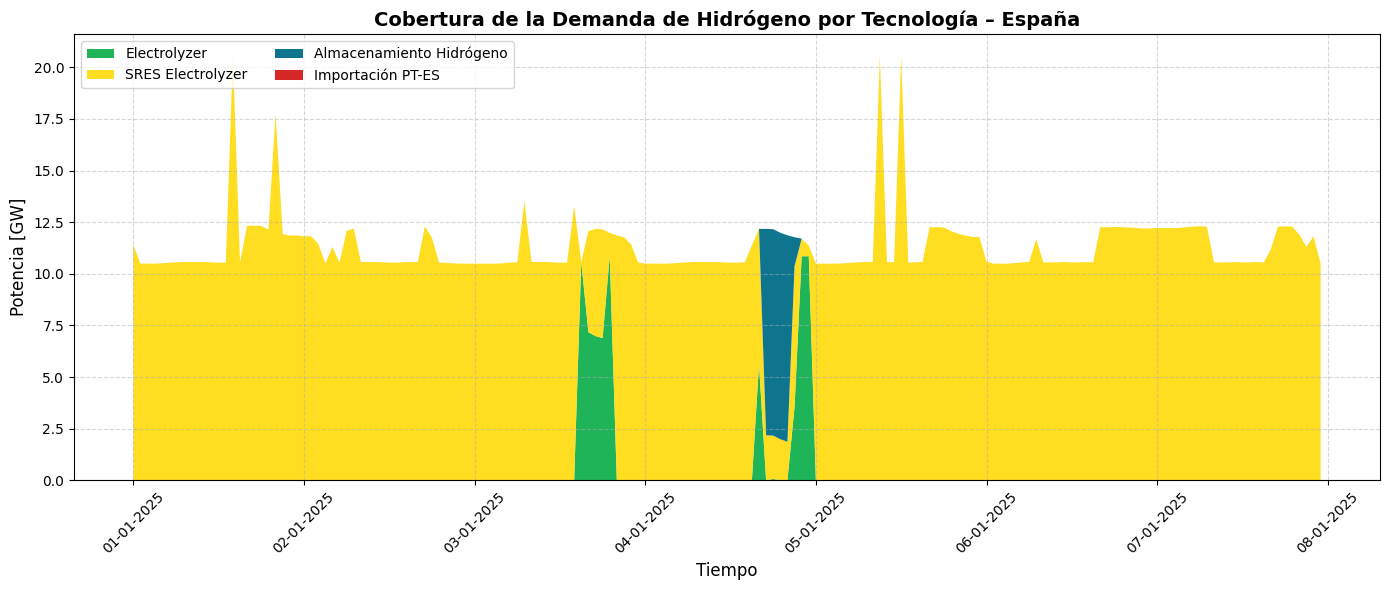

In [593]:
# una grafica con la cobertura de la demanda hidrogeno en España,, que etenemos que tener en cuenta, electrolyzer, electrolyzer_sres, hydrogen_storage, interconexion_hidrogeno
df_h2_plot = pd.DataFrame({
    "ES_electrolyzer":         -network.links_t.p1["ES_electrolyzer"]     / 1e3,
    "ES_SRES_electrolyzer":    -network.links_t.p1["ES_SRES_electrolyzer"] / 1e3,
    "ES_hydrogen_storage":      network.storage_units_t.p["ES_hydrogen_storage"].clip(lower=0) / 1e3,
    "PT_ES_interconexion_hidrogeno": -network.links_t.p1["PT_ES_interconexion_hidrogeno"].clip(upper=0) / 1e3,
}, index=times)
plt.figure(figsize=(14, 6))
plt.stackplot(
    df_h2_plot.index,
    df_h2_plot["ES_electrolyzer"], df_h2_plot["ES_SRES_electrolyzer"], df_h2_plot["ES_hydrogen_storage"], df_h2_plot["PT_ES_interconexion_hidrogeno"],
    labels=["Electrolyzer","SRES Electrolyzer","Almacenamiento Hidrógeno","Importación PT-ES"],
    colors=["#1fb458", "#ffdb0eec", "#0f758f", "#d62728"],
    linewidth=0.0,
)
plt.title("Cobertura de la Demanda de Hidrógeno por Tecnología – España",fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10, ncol=2)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3648931789.py:3: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3648931789.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3648931789.py:5: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



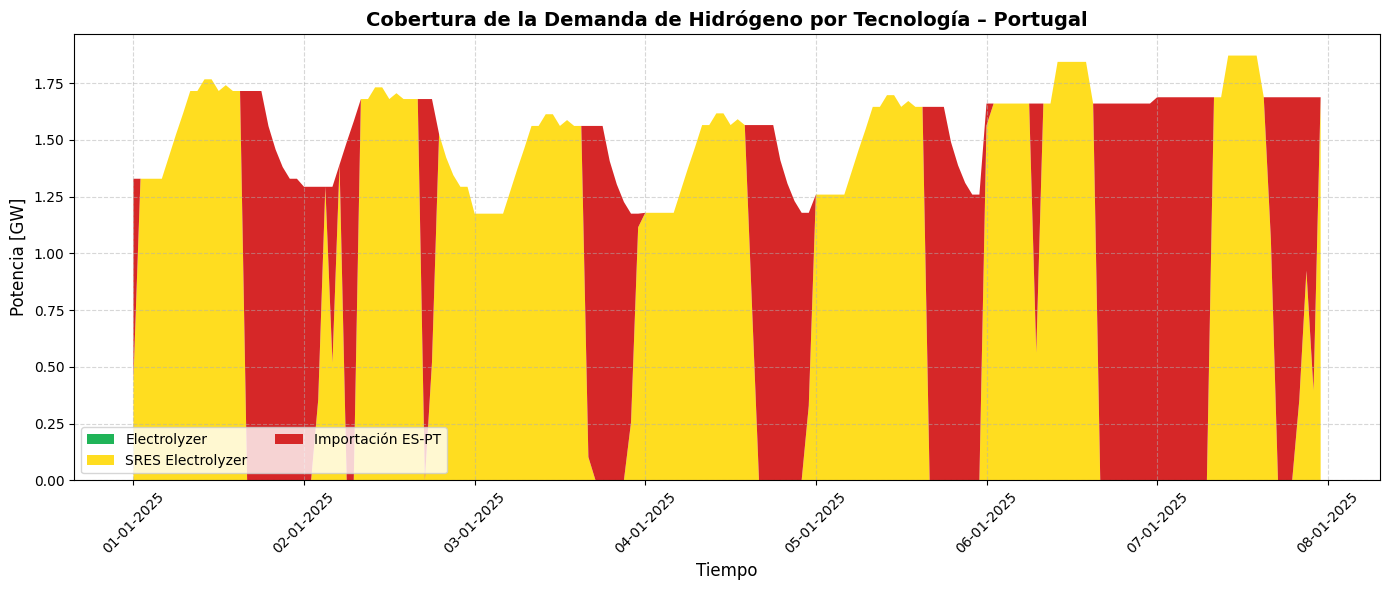

In [594]:
# una grafica con la cobertura de la demanda hidrogeno en España,, que etenemos que tener en cuenta, electrolyzer, electrolyzer_sres, hydrogen_storage, interconexion_hidrogeno
df_h2_plot = pd.DataFrame({
    "PT_electrolyzer":         -network.links_t.p1["PT_electrolyzer"]     / 1e3,
    "PT_SRES_electrolyzer":    -network.links_t.p1["PT_SRES_electrolyzer"] / 1e3,
    "ES_PT_interconexion_hidrogeno": -network.links_t.p1["ES_PT_interconexion_hidrogeno"].clip(upper=0) / 1e3,
}, index=times)
plt.figure(figsize=(14, 6))
plt.stackplot(
    df_h2_plot.index,
    df_h2_plot["PT_electrolyzer"], df_h2_plot["PT_SRES_electrolyzer"], df_h2_plot["ES_PT_interconexion_hidrogeno"],
    labels=["Electrolyzer","SRES Electrolyzer","Importación ES-PT"],
    colors=["#1fb458", "#ffdb0eec", "#d62728"],
    linewidth=0.0,
)
plt.title("Cobertura de la Demanda de Hidrógeno por Tecnología – Portugal",fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left", fontsize=10, ncol=2)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3187169371.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3187169371.py:15: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3187169371.py:22: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\3187169371.py:36: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more informa

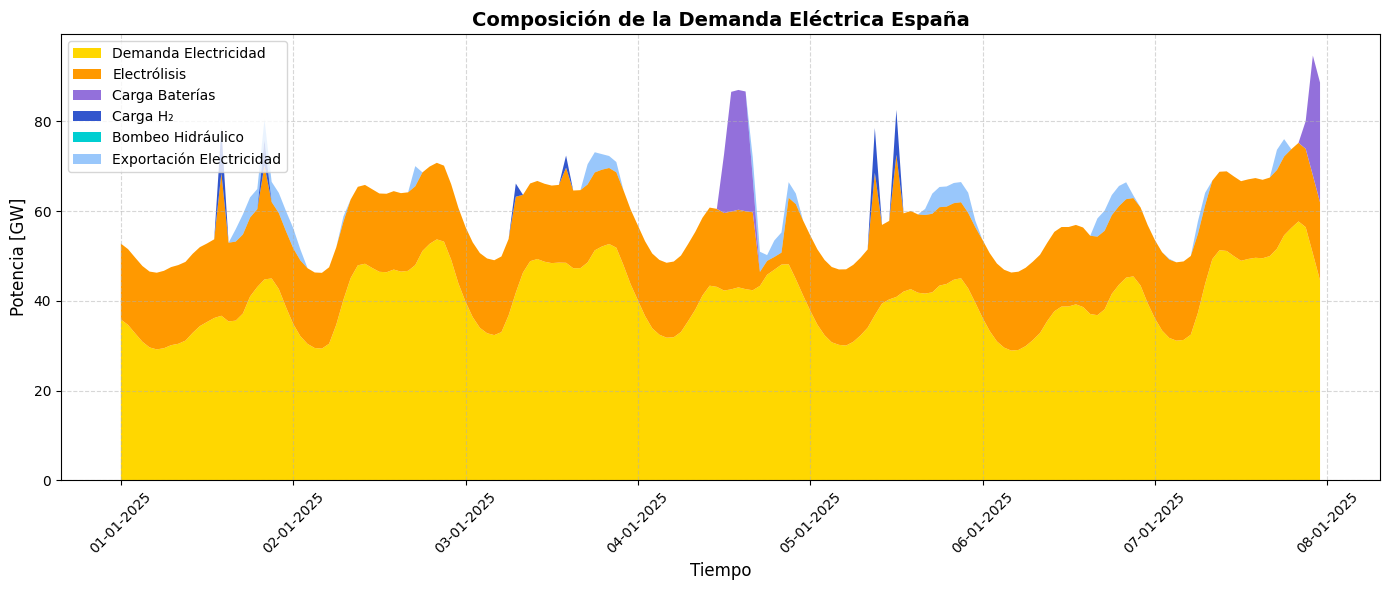

In [595]:
# ----------------------------- DEMANDA NACIONAL -----------------------------
national_electricity_demand = network.loads_t.p_set["ES_demand_2040"] / 1e3   # MW → GW

# ----------------------------- STORAGE UNITS --------------------------------
# En nuevo API: la tabla está en .storage_units.static
su_index = network.storage_units.static.index

# Selección robusta por nombre
battery_sus = [n for n in su_index if "es_electricity_market_battery" in n.lower()]

h2_sus      = [n for n in su_index if "es_hydrogen_storage" in n.lower()]
 
# ------------------------- CARGA DE BATERÍAS / H2 ---------------------------
battery_charge = (
    network.storage_units_t.p[battery_sus]
    .clip(upper=0)               # dejamos solo la carga (valores negativos)
    .sum(axis=1)
    .abs() / 1e3                 # MW → GW
)

h2_charge = (
    network.storage_units_t.p[h2_sus]
    .clip(upper=0)
    .sum(axis=1)
    .abs() / 1e3
)
# ------------------------- BOMBEO HIDRÁULICO --------------------------------
# Nuevo API: nombres en network.links.static.index
link_index = network.links.static.index

pumped_links = [
    l for l in link_index
    if ("es_pump" in l.lower()) or ("es_turbina" in l.lower())
]
pumping_demand = (
    network.links_t.p0[pumped_links]     # p0 positivo = consumo eléctrico
    .clip(lower=0)
    .sum(axis=1) / 1e3                   # MW → GW
)
# --------------------------- ELECTROLIZADORES --------------------------------

electrolyzer_links = [
    l for l in link_index if "es_electrolyzer" in l.lower()
]

electrolyzer_demand = (
    network.links_t.p0[electrolyzer_links]
    .clip(lower=0)
    .sum(axis=1) / 1e3
)

# --------------------------- EXPORTACIONES ELECTRICIDAD  --------------------------------
exportelectricity_links = [
    l for l in link_index if "es_pt_interconexion_electricidad" in l.lower()
]
exportelectricity_demand = (
    network.links_t.p0[exportelectricity_links]
    .clip(lower=0)
    .sum(axis=1) / 1e3
)
# --------------------------- GRÁFICA STACKPLOT -------------------------------
plt.figure(figsize=(14, 6))
plt.stackplot(
     national_electricity_demand.index,
     national_electricity_demand,
     electrolyzer_demand,
     battery_charge,
     h2_charge,
    pumping_demand,
    exportelectricity_demand,
    labels=[
         "Demanda Electricidad",
         "Electrólisis",
         "Carga Baterías",
         "Carga H₂",
         "Bombeo Hidráulico",
        "Exportación Electricidad"
    ],
    colors=[
         "#FFD700",  # Demanda
         "#FF9900",  # Electrólisis
        "#9370DB",  # Carga Baterías
         "#3256CD",  # Carga H2
         "#00CED1",  # Bombeo
        "#2386F776"   # Exportación Electricidad
    ],
    linewidth=0.0,
)

plt.title("Composición de la Demanda Eléctrica España", fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()

# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))

plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\358112589.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\358112589.py:14: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\358112589.py:21: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\358112589.py:35: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information

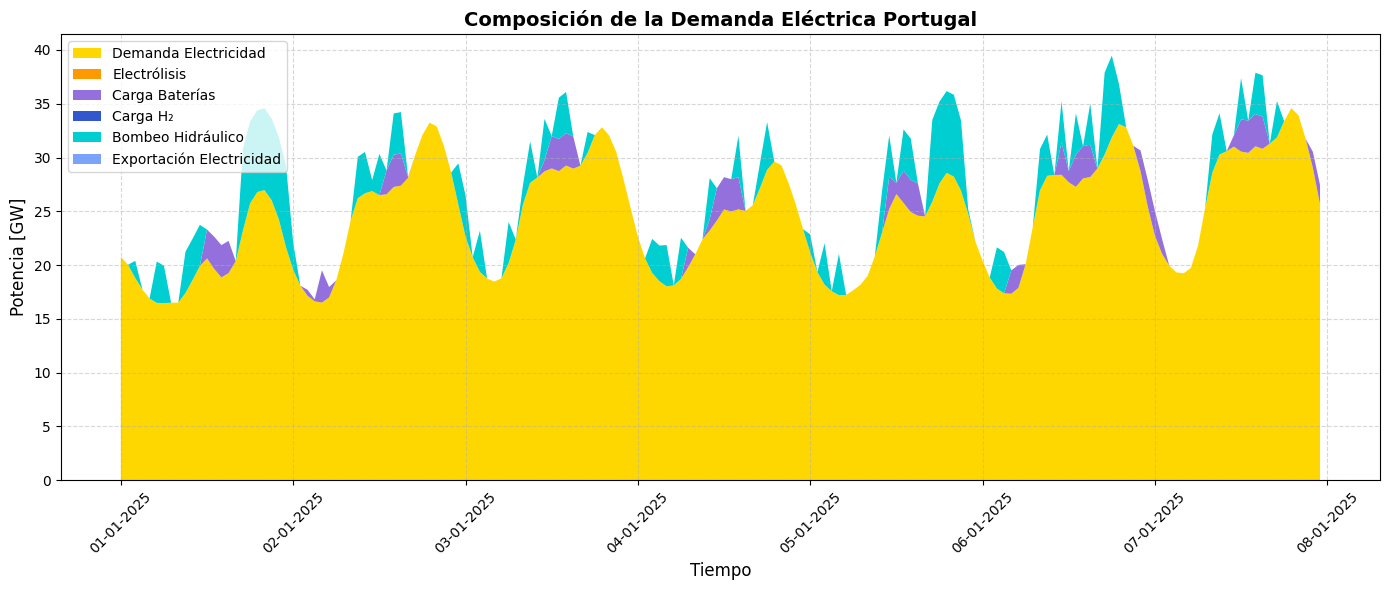

In [596]:
# ----------------------------- DEMANDA NACIONAL -----------------------------
national_electricity_demand = network.loads_t.p_set["PT_demand_2040"] / 1e3   # MW → GW
# ----------------------------- STORAGE UNITS --------------------------------
# En nuevo API: la tabla está en .storage_units.static
su_index = network.storage_units.static.index

# Selección robusta por nombre
battery_sus = [n for n in su_index if "pt_electricity_market_battery" in n.lower()]

h2_sus      = [n for n in su_index if "pt_hydrogen_storage" in n.lower()]

# ------------------------- CARGA DE BATERÍAS / H2 ---------------------------
battery_charge = (
    network.storage_units_t.p[battery_sus]
    .clip(upper=0)               # dejamos solo la carga (valores negativos)
    .sum(axis=1)
    .abs() / 1e3                 # MW → GW
)

h2_charge = (
    network.storage_units_t.p[h2_sus]
    .clip(upper=0)
    .sum(axis=1)
    .abs() / 1e3
)
# ------------------------- BOMBEO HIDRÁULICO --------------------------------
# Nuevo API: nombres en network.links.static.index
link_index = network.links.static.index

pumped_links = [
    l for l in link_index
    if ("pt_pump" in l.lower()) or ("pt_turbina" in l.lower())
]
pumping_demand = (
    network.links_t.p0[pumped_links]     # p0 positivo = consumo eléctrico
    .clip(lower=0)
    .sum(axis=1) / 1e3                   # MW → GW
)
# --------------------------- ELECTROLIZADORES --------------------------------

electrolyzer_links = [
    l for l in link_index if "pt_electrolyzer" in l.lower()
]

electrolyzer_demand = (
    network.links_t.p0[electrolyzer_links]
    .clip(lower=0)
    .sum(axis=1) / 1e3
)

# --------------------------- EXPORTACIONES ELECTRICIDAD  --------------------------------
exportelectricity_links = [
    l for l in link_index if "pt_es_interconexion_electricidad" in l.lower()
]
exportelectricity_demand = (
    network.links_t.p0[exportelectricity_links]
    .clip(lower=0)
    .sum(axis=1) / 1e3
)
# --------------------------- GRÁFICA STACKPLOT -------------------------------
plt.figure(figsize=(14, 6))
plt.stackplot(
     national_electricity_demand.index,
     national_electricity_demand,
     electrolyzer_demand,
     battery_charge,
     h2_charge,
    pumping_demand,
    exportelectricity_demand,
    labels=[
         "Demanda Electricidad",
         "Electrólisis",
         "Carga Baterías",
         "Carga H₂",
         "Bombeo Hidráulico",
        "Exportación Electricidad"
    ],
    colors=[
        "#FFD700",  # Demanda
        "#FF9900",  # Electrólisis
        "#9370DB",  # Carga Baterías
        "#3256CD",  # Carga H2
        "#00CED1",  # Bombeo
        "#2366F799"   # Exportación Electricidad
    ],
    linewidth=0.0,
)

plt.title("Composición de la Demanda Eléctrica Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()

# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))

plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\1308251452.py:7: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



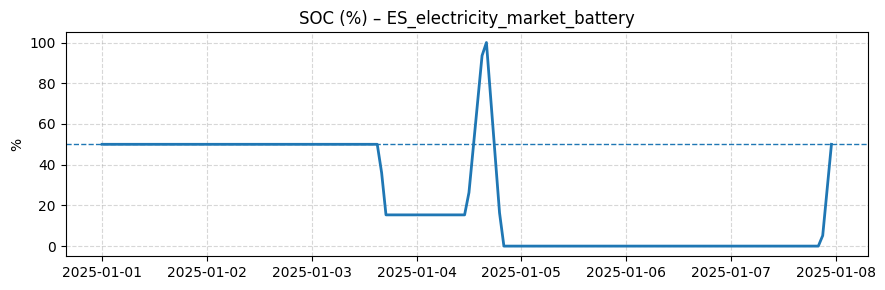

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\1308251452.py:7: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



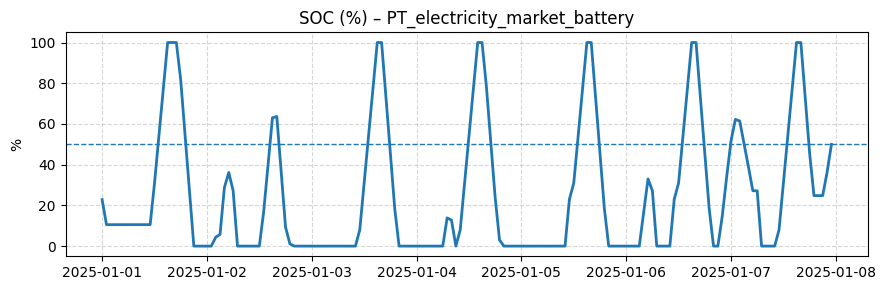

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\1308251452.py:7: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



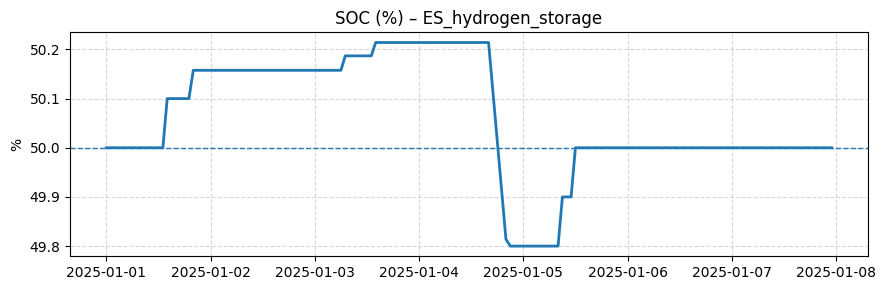

In [597]:

def plot_soc_percent(network, battery_name):
    su = network.storage_units.static
    p_nom = float(su.loc[battery_name, "p_nom"])
    max_hours = float(su.loc[battery_name, "max_hours"])
    Emax = p_nom * max_hours

    soc = network.storage_units_t.state_of_charge[battery_name].astype(float)
    soc_pct = soc / Emax * 100

    plt.figure(figsize=(9,3))
    plt.plot(soc_pct.index, soc_pct, linewidth=2)
    plt.axhline(50, linestyle="--", linewidth=1)
    plt.title(f"SOC (%) – {battery_name}")
    plt.ylabel("%")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_soc_percent(network, "ES_electricity_market_battery")
plot_soc_percent(network, "PT_electricity_market_battery")
plot_soc_percent(network, "ES_hydrogen_storage")


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\2135070050.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\2135070050.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



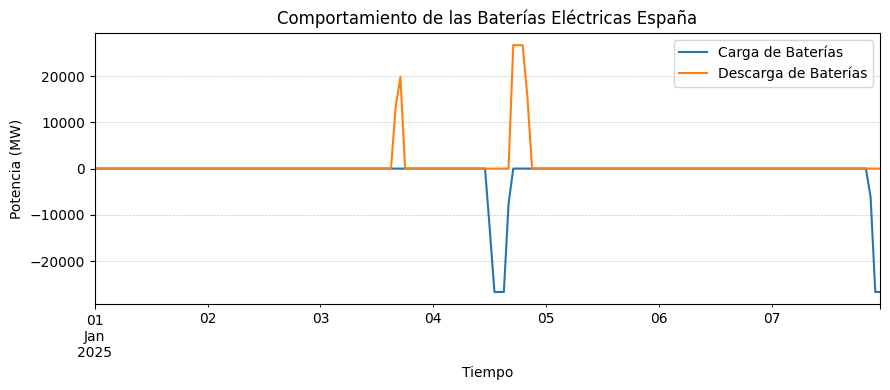

In [598]:
#Grafica de la baterias electricas

#extraemos la serie de carga de las baterias electricas
battery_charge = network.storage_units_t.p["ES_electricity_market_battery"].clip(upper=0)
#extraemos la serie de descarga de las baterias electricas
battery_discharge = network.storage_units_t.p["ES_electricity_market_battery"].clip(lower=0)
#graficamos la carga y descarga de las baterias electricas
plt.figure(figsize=(9,4))
battery_charge.plot(label="Carga de Baterías", color="tab:blue")
battery_discharge.plot(label="Descarga de Baterías", color="tab:orange")
plt.title("Comportamiento de las Baterías Eléctricas España")
plt.ylabel("Potencia (MW)")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

# OJO

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\2875945628.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\2875945628.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



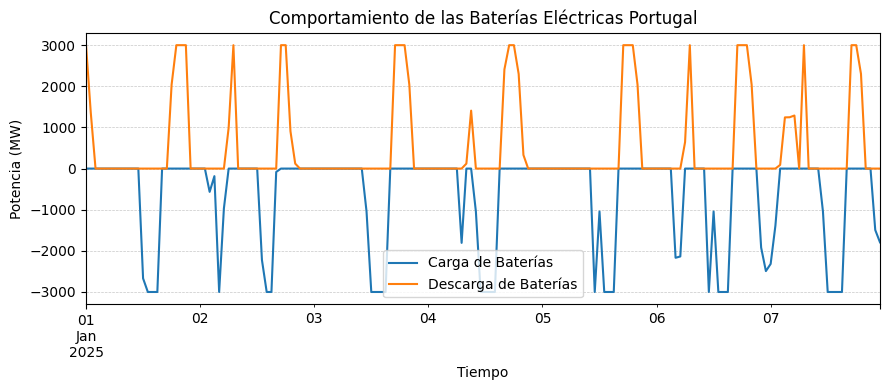

In [599]:
#Grafica de la baterias electricas

#extraemos la serie de carga de las baterias electricas
battery_charge = network.storage_units_t.p["PT_electricity_market_battery"].clip(upper=0)
#extraemos la serie de descarga de las baterias electricas
battery_discharge = network.storage_units_t.p["PT_electricity_market_battery"].clip(lower=0)
#graficamos la carga y descarga de las baterias electricas
plt.figure(figsize=(9,4))
battery_charge.plot(label="Carga de Baterías", color="tab:blue")
battery_discharge.plot(label="Descarga de Baterías", color="tab:orange")
plt.title("Comportamiento de las Baterías Eléctricas Portugal")
plt.ylabel("Potencia (MW)")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\2438572649.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



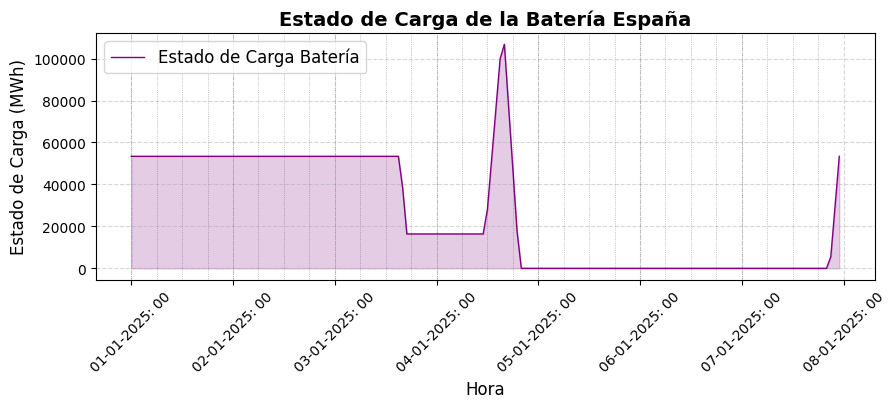

In [600]:
#Grafica del estado de carga de las baterías
soc_batt = network.storage_units_t.state_of_charge["ES_electricity_market_battery"]
plt.figure(figsize=(9,4))
plt.style.use('default')
plt.plot(hours, soc_batt, label="Estado de Carga Batería", color="purple", linewidth=1, linestyle="-")
plt.fill_between(hours, soc_batt, color="purple", alpha=0.2)    
plt.title("Estado de Carga de la Batería España", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Estado de Carga (MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()



C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\2724379132.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



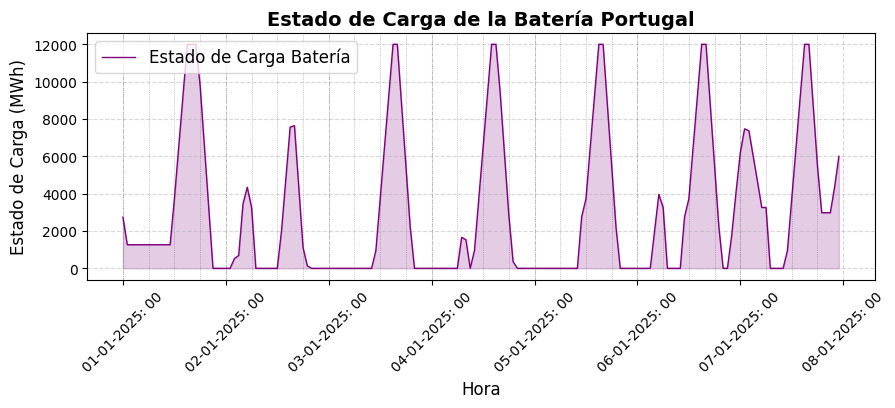

In [601]:
#Grafica del estado de carga de las baterías
soc_batt = network.storage_units_t.state_of_charge["PT_electricity_market_battery"]
plt.figure(figsize=(9,4))
plt.style.use('default')
plt.plot(hours, soc_batt, label="Estado de Carga Batería", color="purple", linewidth=1, linestyle="-")
plt.fill_between(hours, soc_batt, color="purple", alpha=0.2)    
plt.title("Estado de Carga de la Batería Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Estado de Carga (MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_22676\1258577109.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



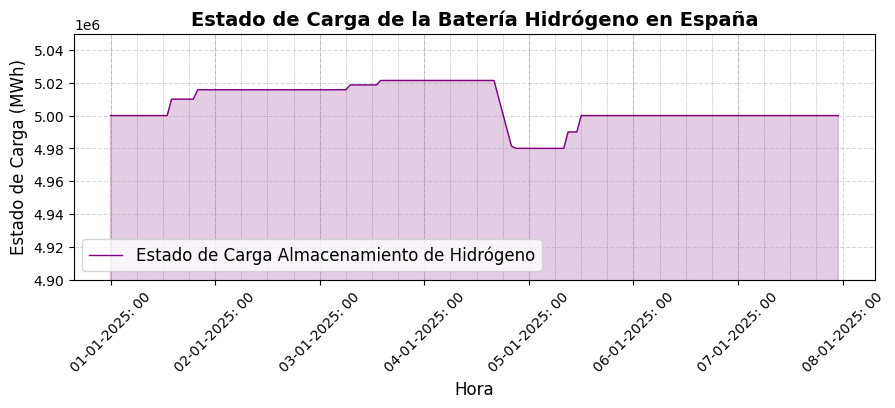

In [602]:
#Grafica del estado de carga de las baterías
soc_batt = network.storage_units_t.state_of_charge["ES_hydrogen_storage"]
plt.figure(figsize=(9,4))
plt.style.use('default')
plt.plot(hours, soc_batt, label="Estado de Carga Almacenamiento de Hidrógeno", color="purple", linewidth=1, linestyle="-")
plt.fill_between(hours, soc_batt, color="purple", alpha=0.2)    
plt.title("Estado de Carga de la Batería Hidrógeno en España", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Estado de Carga (MWh)", fontsize=12)
plt.xticks(rotation=45)

plt.ylim(4900000, 5050000)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left", fontsize=12)
plt.tight_layout()
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()